<h1 style="text-align:center">Data Science & Statistical Computing</h1>
<h2 style="text-align:center">Checkpoint 5 — Random Forest, XGBoost e LightGBM</h2>
<h3 style="text-align:center">Previsão da expectativa de vida ao nascer entre países (regressão supervisionada)</h3>

**Disciplina:** Data Science & Statistical Computing — FIAP 2026 · **Professor:** Jones Egydio · **Entrega:** 01/10/2026

> **Como usar este notebook.** Ele roda de ponta a ponta com *Run All* (tempo típico: poucos minutos, ver nota de desempenho na Seção 0.2). Todos os números, tabelas e leituras interpretativas são **calculados na execução**. A estrutura segue exatamente o enunciado: **4.1 → 4.7**.

<a id="toc"></a>
## Índice — onde está cada item do enunciado

> Cada seção começa com um **banner colorido**; cada item (a, b, c, d) tem um título `4.x (letra)`; e **toda célula de código imprime uma faixa colorida** dizendo em que item você está quando roda *Run All*. Clique no número para pular para a seção.

| Seção | Tema | Pontos | Itens |
|---|---|---|---|
| [**4.1**](#s4_1) | Definição do problema e da base de dados | 1,0 | (a) Contexto, pergunta preditiva e por que supervisionado · (b) Variável-alvo, tipo de problema e significado de ŷ · (c) Fonte, dimensões, unidade observacional e variáveis · (d) Métrica principal e justificativa |
| [**4.2**](#s4_2) | Data wrangling e análise exploratória | 1,5 | (a) Diagnóstico da base · (b) Data wrangling · (c) Visualizações (EDA) — só com o treino · (d) Dimensões após o tratamento + ausências/duplicidades |
| [**4.3**](#s4_3) | Escolha de variáveis e desenho experimental | 1,0 | (a) Definição de X e y, variáveis removidas e justificativas · (b) Separação treino/teste e validação cruzada · (c) Métrica principal e métricas auxiliares |
| [**4.4**](#s4_4) | Implementação dos três modelos de referência (baseline) | 1,5 | (a) Random Forest de referência · (b) XGBoost de referência · (c) LightGBM de referência · (d) Tabela única, interpretação e sinais de over/underfitting |
| [**4.5**](#s4_5) | Tuning com Grid Search e Optuna | 2,0 | (a) Grid Search · (b) Optuna · (c) Comparação Grid Search × Optuna |
| [**4.6**](#s4_6) | Escolha do melhor modelo e análise de overfitting/underfitting | 1,5 | (a) Tabela das 9 configurações e escolha · (b) Treino × validação e curva de aprendizado · (c) Importância das variáveis e gráficos de desempenho |
| [**4.7**](#s4_7) | Teste final, consistência, GitHub e Streamlit | 1,5 | (a) Avaliação final no teste (uma única vez) · (b) Teste de consistência (≥ 5 observações) · (c) GitHub, Streamlit e teste de paridade |
| [**5**](#conclusao) | Conclusão e checklist | — | Resumo calculado dos resultados e verificação de conformidade |

## 0.1 Identificação do projeto

Nomes e RMs dos integrantes (exigência do enunciado) e, ao final do projeto, os links do GitHub e do Streamlit.

In [1]:
# >>> EDITE AQUI <<<
INTEGRANTES = [
    ("Enzo Fernandes Ramos", "RM 563705"),
    ("Felipe Henrique de Souza Cerazi", "RM 562746"),
    ("Gustavo Peaguda de Castro", "RM 562923"),
    ("Lorenzo Andolfatto Coque", "RM 563385"),
]
GITHUB_URL = ""      # link final do repositório
STREAMLIT_URL = ""   # link final da aplicação

from IPython.display import display, Markdown
def md(texto): display(Markdown(texto))

def secao(codigo, titulo, cor="#1f4e79"):
    # Banner colorido impresso como SAÍDA de cada célula: mostra, durante o Run All, em qual item (4.x) você está.
    display(Markdown(f'<div style="background:{cor};color:white;padding:8px 14px;border-radius:6px;font-size:16px;margin:6px 0">'
                     f'<b>▶ {codigo}</b> &nbsp;|&nbsp; {titulo}</div>'))

def secao(codigo, titulo, cor="#1f4e79"):
    """Banner colorido impresso como SAÍDA de cada célula: mostra, durante o Run All, em qual item (4.x) você está."""
    display(Markdown(f'<div style="background:{cor};color:white;padding:8px 14px;border-radius:6px;font-size:16px;margin:6px 0">'
                     f'<b>▶ {codigo}</b> &nbsp;|&nbsp; {titulo}</div>'))

linhas = "\n".join(f"| {n or '*(preencher)*'} | {r or '*(preencher)*'} |" for n, r in INTEGRANTES)
md("| Integrante | RM |\n|---|---|\n" + linhas)
md(f"**GitHub:** {GITHUB_URL or '*https://github.com/Gustavo-Peaguda/CP5-DataScience*'}  ")

| Integrante | RM |
|---|---|
| Enzo Fernandes Ramos | RM 563705 |
| Felipe Henrique de Souza Cerazi | RM 562746 |
| Gustavo Peaguda de Castro | RM 562923 |
| Lorenzo Andolfatto Coque | RM 563385 |

**GitHub:** *https://github.com/Gustavo-Peaguda/CP5-DataScience*  

**Objetivo.** Projeto completo de regressão supervisionada que compara **Random Forest**, **XGBoost** e **LightGBM** sob um mesmo protocolo experimental (mesmo conjunto de teste, mesmos folds, mesma métrica principal, mesma preparação), com tuning por **Grid Search** e **Optuna**, análise de overfitting/underfitting, avaliação final isolada e exportação do pipeline para o **Streamlit**.

**Escopo das variáveis.** Este projeto **não usa todas as colunas da base**: as variáveis ligadas a **doenças** (HIV/AIDS, hepatite B, pólio, difteria, sarampo) foram retiradas, assim como identificadores, variáveis redundantes e dados implausíveis (justificativas na Seção 4.3).

## 0.2 Preparação do ambiente

In [2]:

import sys, subprocess, importlib.util
def ensure_package(import_name, pip_name=None):
    if importlib.util.find_spec(import_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name or import_name])
for _pkg in ["xgboost", "lightgbm", "optuna"]:
    ensure_package(_pkg)

import warnings, time, json, os, platform
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

from sklearn.model_selection import GroupShuffleSplit, GridSearchCV, cross_validate, cross_val_predict, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.dummy import DummyRegressor
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import sklearn, joblib
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import optuna, xgboost, lightgbm

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option("display.max_columns", 60); pd.set_option("display.width", 220); pd.set_option("display.max_colwidth", 140)
pd.options.display.float_format = "{:,.3f}".format
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold"})

SEED = 42
# Desempenho: a base é pequena; o gargalo é o nº de ajustes. Paralelizamos ENTRE os folds de CV
# (cada modelo usa 1 thread), o que é mais rápido que paralelizar dentro de cada árvore em dados pequenos.
N_JOBS = max(1, min(5, os.cpu_count() or 1))

DIR_DADOS = Path("dados")
ARQ_BRUTO  = DIR_DADOS / "vida_expectativa_kaggle_bruto.csv"   # base Kaggle/OMS
ARQ_REGIAO = DIR_DADOS / "paises_iso_regiao.csv"               # tabela auxiliar de regiões
assert ARQ_BRUTO.exists() and ARQ_REGIAO.exists(), f"CSVs não encontrados em {DIR_DADOS.resolve()} — abra o notebook na raiz do projeto."
Path("modelo").mkdir(exist_ok=True)

def mostrar(df, fmt=None, gradiente=None, cmap="Greens_r"):
    """Exibe uma tabela garantindo que NENHUMA célula esteja vazia (NaN/None)."""
    vazias = df.isna().sum()
    assert vazias.sum() == 0, f"Tabela com células vazias nas colunas: {vazias[vazias > 0].to_dict()}"
    if fmt is None and gradiente is None:
        display(df); return
    sty = df.style
    if fmt: sty = sty.format(fmt)
    if gradiente: sty = sty.background_gradient(subset=gradiente, cmap=cmap)
    display(sty)

print(f"Ambiente OK · {N_JOBS} processo(s) em paralelo na validação cruzada · dados em: {DIR_DADOS.resolve()}")

Ambiente OK · 5 processo(s) em paralelo na validação cruzada · dados em: C:\Users\labsfiap\Desktop\CP5-DataScience\CP5-DataScience\projeto_checkpoint5\dados


c:\python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Nota de desempenho.** Para que o notebook rode rápido sem perder rigor: (i) o paralelismo é feito entre os folds; (ii) o número de árvores é moderado (100–300) e a taxa de aprendizado é parte da busca; (iii) as grades têm 24 combinações por modelo e o Optuna usa 20 *trials* por modelo (mínimo exigido); (iv) a importância por permutação usa poucas repetições. Cada célula pesada informa o tempo gasto.

<a id="s4_1"></a>
<div style="background:#1f4e79;color:white;padding:18px 22px;border-radius:10px;margin:28px 0 8px 0"><div style="font-size:15px;opacity:.85">SEÇÃO 4.1 &nbsp; <a href="#toc" style="color:#fff;text-decoration:underline">↑ voltar ao índice</a></div><div style="font-size:28px;font-weight:bold;margin:4px 0 8px 0">4.1 — Definição do problema e da base de dados</div><ul style="margin:0;padding-left:20px;font-size:14px"><li><b>(a)</b> Contexto, pergunta preditiva e por que supervisionado </li><li><b>(b)</b> Variável-alvo, tipo de problema e significado de ŷ</li><li><b>(c)</b> Fonte, dimensões, unidade observacional e variáveis </li><li><b>(d)</b> Métrica principal e justificativa </li></ul></div>

### <span style="color:#1f4e79">4.1 (a)</span> — Contexto, pergunta preditiva e por que supervisionado  

**Contexto.** A expectativa de vida ao nascer é um indicador-síntese de saúde pública, acompanhado pela OMS/ONU, e varia muito entre países e ao longo do tempo. A pergunta preditiva é:

> *Dadas características socioeconômicas, demográficas e de gasto em saúde observadas para um país em determinado ano, qual é a expectativa de vida ao nascer daquele país-ano?*

**Por que aprendizado supervisionado?** A base traz o valor observado do alvo para milhares de pares país-ano, e queremos aprender $f:\mathbf{x}\mapsto y$ que **generalize para países não vistos**. Métodos de árvores capturam relações não lineares e interações sem exigir forma funcional prévia. `ano` entra apenas como variável explicativa (nível/tendência do painel); o modelo **não** é de previsão de anos futuros.

### <span style="color:#1f4e79">4.1 (b)</span> — Variável-alvo, tipo de problema e significado de $\hat y$  

$y$ = **expectativa de vida ao nascer (anos)** → **problema de REGRESSÃO**. $\hat y_i$ é a expectativa de vida **prevista** (em anos) para o país-ano $i$; o erro individual é $e_i=y_i-\hat y_i$ (positivo = o modelo subestimou).

### <span style="color:#1f4e79">4.1 (c)</span> — Fonte, obtenção, dimensões, unidade observacional e variáveis  

**Fonte.** Dataset *Life Expectancy (WHO)* (Kaggle, `kumarajarshi/life-expectancy-who`), compilado de dados públicos da OMS (Global Health Observatory) e da ONU, guardado na pasta `dados/`. A tabela auxiliar `paises_iso_regiao.csv` (ISO 3166-1, com continente) adiciona `regiao`. **Unidade observacional: um país em um ano (país-ano).** Dimensões e dicionário de dados abaixo.

In [3]:
secao("4.1 (c)", "Carrega a base bruta, padroniza os nomes das colunas (snake_case, em português) e mostra o dicionario", "#1f4e79")
# Carrega a base bruta, padroniza os nomes das colunas (snake_case, em português) e mostra o dicionário de dados
RENOMEAR = {
 "Country":"pais", "Year":"ano", "Status":"status", "Life expectancy":"expectativa_vida",
 "Adult Mortality":"mortalidade_adulta", "infant deaths":"obitos_infantis", "Alcohol":"alcool",
 "percentage expenditure":"gasto_saude_pct_pib_pc", "Hepatitis B":"hepatite_b", "Measles":"sarampo",
 "BMI":"imc", "under-five deaths":"obitos_menores_5", "Polio":"polio", "Total expenditure":"gasto_saude_total_pct",
 "Diphtheria":"difteria", "HIV/AIDS":"hiv_aids", "GDP":"pib_per_capita", "Population":"populacao",
 "thinness  1-19 years":"magreza_1_19", "thinness 5-9 years":"magreza_5_9",
 "Income composition of resources":"indice_renda", "Schooling":"escolaridade_anos",
}
bruto = pd.read_csv(ARQ_BRUTO)
bruto.columns = bruto.columns.str.strip()
faltando = set(RENOMEAR) - set(bruto.columns)
assert not faltando, f"Colunas esperadas ausentes: {faltando}"
df_bruto = bruto.rename(columns=RENOMEAR)
reg = pd.read_csv(ARQ_REGIAO)

# Dicionário de dados (variável, tipo, significado, unidade)
DIC_BASE = [
 ("pais","texto","Nome do país","—"),
 ("ano","inteiro","Ano de referência (2000–2015)","ano"),
 ("status","categórica","Status de desenvolvimento (Developed / Developing)","categoria"),
 ("expectativa_vida","float","Expectativa de vida ao nascer — ALVO (y)","anos"),
 ("mortalidade_adulta","float","Mortalidade adulta (15–60 anos)","por 1.000 adultos"),
 ("obitos_infantis","inteiro","Óbitos infantis","contagem"),
 ("alcool","float","Consumo de álcool per capita","litros"),
 ("gasto_saude_pct_pib_pc","float","Gasto em saúde (percentage expenditure, definição da fonte)","% do PIB per capita"),
 ("hepatite_b","float","Cobertura vacinal Hepatite B","% de cobertura"),
 ("sarampo","inteiro","Casos de sarampo notificados","casos"),
 ("imc","float","IMC médio","kg/m²"),
 ("obitos_menores_5","inteiro","Óbitos de menores de 5 anos","contagem"),
 ("polio","float","Cobertura vacinal Pólio","% de cobertura"),
 ("gasto_saude_total_pct","float","Gasto total em saúde (% do gasto governamental)","% do gasto governamental"),
 ("difteria","float","Cobertura vacinal Difteria (DTP3)","% de cobertura"),
 ("hiv_aids","float","Mortes por HIV/AIDS por 1.000 nascidos vivos (0–4 anos)","por 1.000 nasc. vivos"),
 ("pib_per_capita","float","PIB per capita","US$"),
 ("populacao","float","População","habitantes"),
 ("magreza_1_19","float","Prevalência de magreza em 10–19 anos (nome original '1–19')","%"),
 ("magreza_5_9","float","Prevalência de magreza em 5–9 anos","%"),
 ("indice_renda","float","Composição de renda dos recursos (índice tipo IDH)","índice 0–1"),
 ("escolaridade_anos","float","Anos médios de escolaridade","anos"),
 ("regiao","categórica","Continente/região (tabela ISO auxiliar)","categoria"),
]
assert set(df_bruto.columns) | {"regiao"} == {v[0] for v in DIC_BASE}, "Dicionário de dados não cobre todas as colunas"

md(f"**Dimensões iniciais:** {df_bruto.shape[0]:,} linhas × {df_bruto.shape[1]} colunas · **países:** {df_bruto['pais'].nunique()} · "
   f"**anos:** {df_bruto['ano'].min()}–{df_bruto['ano'].max()} · **unidade observacional:** país-ano.")
md("**Dicionário de dados**")
mostrar(pd.DataFrame(DIC_BASE, columns=["variável", "tipo", "significado", "unidade"]))
md("**Amostra de 5 linhas completas da base** (apenas para ilustrar o formato; linhas com dado faltante foram omitidas desta amostra):")
mostrar(df_bruto.dropna().sample(5, random_state=SEED).reset_index(drop=True))

<div style="background:#1f4e79;color:white;padding:8px 14px;border-radius:6px;font-size:16px;margin:6px 0"><b>▶ 4.1 (c)</b> &nbsp;|&nbsp; Carrega a base bruta, padroniza os nomes das colunas (snake_case, em português) e mostra o dicionario</div>

**Dimensões iniciais:** 2,938 linhas × 22 colunas · **países:** 193 · **anos:** 2000–2015 · **unidade observacional:** país-ano.

**Dicionário de dados**

,variável,tipo,significado,unidade
0,pais,texto,Nome do país,—
1,ano,inteiro,Ano de referência (2000–2015),ano
2,status,categórica,Status de desenvolvimento (Developed / Developing),categoria
3,expectativa_vida,float,Expectativa de vida ao nascer — ALVO (y),anos
4,mortalidade_adulta,float,Mortalidade adulta (15–60 anos),por 1.000 adultos
5,obitos_infantis,inteiro,Óbitos infantis,contagem
6,alcool,float,Consumo de álcool per capita,litros
7,gasto_saude_pct_pib_pc,float,"Gasto em saúde (percentage expenditure, definição da fonte)",% do PIB per capita
8,hepatite_b,float,Cobertura vacinal Hepatite B,% de cobertura
9,sarampo,inteiro,Casos de sarampo notificados,casos


**Amostra de 5 linhas completas da base** (apenas para ilustrar o formato; linhas com dado faltante foram omitidas desta amostra):

,pais,ano,status,expectativa_vida,mortalidade_adulta,obitos_infantis,alcool,gasto_saude_pct_pib_pc,hepatite_b,sarampo,imc,obitos_menores_5,polio,gasto_saude_total_pct,difteria,hiv_aids,pib_per_capita,populacao,magreza_1_19,magreza_5_9,indice_renda,escolaridade_anos
0,Indonesia,2007,Developing,67.500,19.000,154,0.060,102.633,76.000,19456,2.500,188,77.000,3.100,73.000,0.200,"1,855.939","232,989,141.000",1.800,1.700,0.638,11.000
1,Serbia,2007,Developing,73.800,132.000,1,9.300,772.870,99.000,201,55.100,1,93.000,1.200,94.000,0.100,"5,458.122","7,381,579.000",2.400,2.400,0.743,13.500
2,Germany,2004,Developed,79.100,86.000,3,11.830,"5,842.375",88.000,121,57.100,3,96.000,1.370,96.000,0.100,"34,165.934","8,251,626.000",1.100,1.100,0.877,16.400
3,Zimbabwe,2011,Developing,54.900,464.000,28,6.000,63.751,94.000,0,29.900,42,93.000,6.310,93.000,13.300,839.928,"14,386,649.000",6.800,6.700,0.452,10.100
4,Central African Republic,2009,Developing,48.600,453.000,17,1.560,40.452,42.000,11,19.800,25,45.000,3.580,42.000,7.300,449.962,"44,423.000",9.100,9.100,0.345,6.400


### <span style="color:#1f4e79">4.1 (d)</span> — Métrica principal e justificativa  <small style="color:gray">· 0,25 pt</small>

**Métrica principal: RMSE (anos).** Está na mesma unidade do alvo, penaliza mais os erros grandes (os mais graves ao prever a expectativa de vida de um país) e é o critério de otimização de Grid Search e Optuna. Auxiliares: **MAE** (erro típico) e **R²** (variância explicada). A escolha foi feita *a priori*, pelo critério do problema.

<a id="s4_2"></a>
<div style="background:#2e7d32;color:white;padding:18px 22px;border-radius:10px;margin:28px 0 8px 0"><div style="font-size:15px;opacity:.85">SEÇÃO 4.2 &nbsp; <a href="#toc" style="color:#fff;text-decoration:underline">↑ voltar ao índice</a></div><div style="font-size:28px;font-weight:bold;margin:4px 0 8px 0">4.2 — Data wrangling e análise exploratória</div><ul style="margin:0;padding-left:20px;font-size:14px"><li><b>(a)</b> Diagnóstico da base </li><li><b>(b)</b> Data wrangling </li><li><b>(c)</b> Visualizações (EDA) — só com o treino </li><li><b>(d)</b> Dimensões após o tratamento + ausências/duplicidades </li></ul></div>

### <span style="color:#2e7d32">4.2 (a)</span> — Diagnóstico da base bruta  

Tipos, ausências, duplicidades, categorias inconsistentes e valores impossíveis. Esta etapa é **descritiva de qualidade de dados**; nenhuma decisão de seleção de variáveis usa o alvo aqui.

In [4]:
secao("4.2 (a)", "Tipos, ausências e estatísticas — tabelas sem células vazias", "#2e7d32")
# (a) Tipos, ausências e estatísticas — tabelas sem células vazias
md("**Tipos e ausências por coluna**")
diag = pd.DataFrame({"tipo": df_bruto.dtypes.astype(str), "n_ausentes": df_bruto.isna().sum(),
                     "% ausentes": df_bruto.isna().mean() * 100, "n_únicos": df_bruto.nunique()})
mostrar(diag, fmt={"n_ausentes": "{:,.0f}", "% ausentes": "{:.1f}", "n_únicos": "{:,.0f}"})

md("**Estatísticas descritivas (colunas numéricas, sobre os valores não ausentes)**")
num_bruto = df_bruto.select_dtypes("number")
est = num_bruto.describe().T[["count", "mean", "min", "50%", "max"]].rename(columns={"count": "n", "mean": "média", "50%": "mediana"})
mostrar(est, fmt={"n": "{:,.0f}", "média": "{:,.2f}", "min": "{:,.2f}", "mediana": "{:,.2f}", "max": "{:,.2f}"})

<div style="background:#2e7d32;color:white;padding:8px 14px;border-radius:6px;font-size:16px;margin:6px 0"><b>▶ 4.2 (a)</b> &nbsp;|&nbsp; Tipos, ausências e estatísticas — tabelas sem células vazias</div>

**Tipos e ausências por coluna**

,tipo,n_ausentes,% ausentes,n_únicos
pais,str,0,0.0,193
ano,int64,0,0.0,16
status,str,0,0.0,2
expectativa_vida,float64,10,0.3,362
mortalidade_adulta,float64,10,0.3,425
obitos_infantis,int64,0,0.0,209
alcool,float64,194,6.6,"1,076"
gasto_saude_pct_pib_pc,float64,0,0.0,"2,328"
hepatite_b,float64,553,18.8,87
sarampo,int64,0,0.0,958


**Estatísticas descritivas (colunas numéricas, sobre os valores não ausentes)**

,n,média,min,mediana,max
ano,"2,938","2,007.52","2,000.00","2,008.00","2,015.00"
expectativa_vida,"2,928",69.22,36.30,72.10,89.00
mortalidade_adulta,"2,928",164.80,1.00,144.00,723.00
obitos_infantis,"2,938",30.30,0.00,3.00,"1,800.00"
alcool,"2,744",4.60,0.01,3.75,17.87
gasto_saude_pct_pib_pc,"2,938",738.25,0.00,64.91,"19,479.91"
hepatite_b,"2,385",80.94,1.00,92.00,99.00
sarampo,"2,938","2,419.59",0.00,17.00,"212,183.00"
imc,"2,904",38.32,1.00,43.50,87.30
obitos_menores_5,"2,938",42.04,0.00,4.00,"2,500.00"


In [5]:
secao("4.2 (a)", "Duplicidades, categorias e valores impossíveis/suspeitos (regras de plausibilidade; não alteram", "#2e7d32")
# (a) Duplicidades, categorias e valores impossíveis/suspeitos (regras de plausibilidade; não alteram a base)
dup_linha = int(df_bruto.duplicated().sum()); dup_chave = int(df_bruto.duplicated(["pais", "ano"]).sum())
obs_por_pais = df_bruto.groupby("pais").size()
espacos = int(sum((df_bruto[c].astype(str) != df_bruto[c].astype(str).str.strip()).sum() for c in ["pais", "status"]))
sem_regiao = sorted(set(df_bruto["pais"]) - set(reg["pais"]))
md("**Duplicidades e consistência de categorias**")
mostrar(pd.DataFrame({"verificação": ["Linhas totalmente duplicadas", "Duplicidade da chave (pais, ano)", "Categorias de `status`",
                                      "Países com status diferente ao longo dos anos (máx.)", "Países com nº de anos ≠ 16",
                                      "Espaços extras em `pais`/`status`", "Países da base sem região na tabela auxiliar"],
                      "resultado": [str(dup_linha), str(dup_chave), ", ".join(sorted(df_bruto["status"].unique())),
                                    str(int(df_bruto.groupby("pais")["status"].nunique().max())), str(int((obs_por_pais != 16).sum())),
                                    str(espacos), f"{len(sem_regiao)}" + (f" ({', '.join(sem_regiao)})" if sem_regiao else "")]}))

d = df_bruto
cobertura = ["hepatite_b", "polio", "difteria"]
regras = {
 "indice_renda == 0 (não plausível como índice observado)": d["indice_renda"].eq(0),
 "escolaridade_anos == 0": d["escolaridade_anos"].eq(0),
 "imc fora de [15, 40] (IMC médio nacional implausível)": d["imc"].notna() & ~d["imc"].between(15, 40),
 "cobertura vacinal fora de [0, 100] %": (d[cobertura].lt(0) | d[cobertura].gt(100)).any(axis=1),
 "expectativa_vida fora de [30, 95] anos": d["expectativa_vida"].notna() & ~d["expectativa_vida"].between(30, 95),
 "populacao <= 0": d["populacao"].le(0), "pib_per_capita <= 0": d["pib_per_capita"].le(0),
 "alcool < 0": d["alcool"].lt(0), "mortalidade_adulta <= 0": d["mortalidade_adulta"].le(0),
}
tab_regras = pd.DataFrame({"n_linhas": {k: int(v.sum()) for k, v in regras.items()}})
tab_regras["% das linhas"] = tab_regras["n_linhas"] / len(d) * 100
md("**Valores impossíveis ou suspeitos**")
mostrar(tab_regras, fmt={"n_linhas": "{:,.0f}", "% das linhas": "{:.2f}"})

z_ir, z_es = d["indice_renda"].eq(0), d["escolaridade_anos"].eq(0)
md(f"**Evidência sobre os zeros.** Menor valor *não nulo* de `indice_renda`: **{d.loc[~z_ir & d['indice_renda'].notna(), 'indice_renda'].min():.3f}**; "
   f"de `escolaridade_anos`: **{d.loc[~z_es & d['escolaridade_anos'].notna(), 'escolaridade_anos'].min():.1f}**. "
   f"Os zeros aparecem em **{d.loc[z_ir, 'pais'].nunique()}** países (`indice_renda`) e **{d.loc[z_es, 'pais'].nunique()}** (`escolaridade_anos`), "
   f"coincidindo em {int((z_ir & z_es).sum())} linhas — comportamento típico de código de 'sem dado', não de medição real. "
   f"O `imc` tem {int(regras['imc fora de [15, 40] (IMC médio nacional implausível)'].sum())} valores implausíveis para uma média nacional.")

<div style="background:#2e7d32;color:white;padding:8px 14px;border-radius:6px;font-size:16px;margin:6px 0"><b>▶ 4.2 (a)</b> &nbsp;|&nbsp; Duplicidades, categorias e valores impossíveis/suspeitos (regras de plausibilidade; não alteram</div>

**Duplicidades e consistência de categorias**

,verificação,resultado
0,Linhas totalmente duplicadas,0
1,"Duplicidade da chave (pais, ano)",0
2,Categorias de `status`,"Developed, Developing"
3,Países com status diferente ao longo dos anos (máx.),1
4,Países com nº de anos ≠ 16,10
5,Espaços extras em `pais`/`status`,0
6,Países da base sem região na tabela auxiliar,0


**Valores impossíveis ou suspeitos**

,n_linhas,% das linhas
indice_renda == 0 (não plausível como índice observado),130,4.42
escolaridade_anos == 0,28,0.95
"imc fora de [15, 40] (IMC médio nacional implausível)","1,942",66.10
"cobertura vacinal fora de [0, 100] %",0,0.00
"expectativa_vida fora de [30, 95] anos",0,0.00
populacao <= 0,0,0.00
pib_per_capita <= 0,0,0.00
alcool < 0,0,0.00
mortalidade_adulta <= 0,0,0.00


**Evidência sobre os zeros.** Menor valor *não nulo* de `indice_renda`: **0.253**; de `escolaridade_anos`: **2.8**. Os zeros aparecem em **31** países (`indice_renda`) e **10** (`escolaridade_anos`), coincidindo em 26 linhas — comportamento típico de código de 'sem dado', não de medição real. O `imc` tem 1942 valores implausíveis para uma média nacional.

<div style="background:#2e7d32;color:white;padding:8px 14px;border-radius:6px;font-size:16px;margin:6px 0"><b>▶ 4.2 (a)</b> &nbsp;|&nbsp; Gráfico 1 — percentual de valores ausentes por coluna (base bruta)</div>

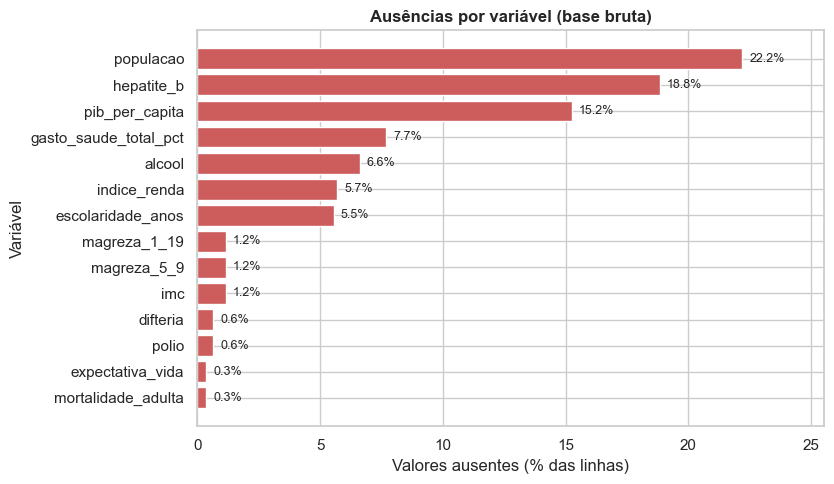

**Interpretação.** As maiores lacunas estão em `populacao` (22.2%), `hepatite_b` (18.8%), `pib_per_capita` (15.2%). Ausência não é aleatória (países pequenos ou sem registro), então **não removemos linhas por falta de dado nas preditoras**: a imputação é feita dentro do `Pipeline`, ajustada apenas no treino de cada fold (sem vazamento). Só são removidas as linhas sem alvo.

In [6]:
secao("4.2 (a)", "Gráfico 1 — percentual de valores ausentes por coluna (base bruta)", "#2e7d32")
# (a) Gráfico 1 — percentual de valores ausentes por coluna (base bruta)
aus = (df_bruto.isna().mean() * 100).sort_values(ascending=False); aus = aus[aus > 0]
fig, ax = plt.subplots(figsize=(8.5, 5))
ax.barh([c for c in aus.index][::-1], aus.values[::-1], color="indianred")
for i, v in enumerate(aus.values[::-1]): ax.text(v + .3, i, f"{v:.1f}%", va="center", fontsize=9)
ax.set_xlabel("Valores ausentes (% das linhas)"); ax.set_ylabel("Variável"); ax.set_title("Ausências por variável (base bruta)")
ax.set_xlim(0, aus.max() * 1.15); plt.tight_layout(); plt.show()
md(f"**Interpretação.** As maiores lacunas estão em " + ", ".join(f"`{c}` ({v:.1f}%)" for c, v in aus.head(3).items()) +
   ". Ausência não é aleatória (países pequenos ou sem registro), então **não removemos linhas por falta de dado nas preditoras**: a imputação é feita dentro do `Pipeline`, "
   "ajustada apenas no treino de cada fold (sem vazamento). Só são removidas as linhas sem alvo.")

### <span style="color:#2e7d32">4.2 (b)</span> — Data wrangling 

Cada transformação abaixo é **determinística e não aprende parâmetros dos dados** (renomear, recodificar códigos de ausência, remover linhas sem alvo, remover duplicatas). Por isso pode ser feita antes da separação treino/teste sem vazamento. A **imputação** e a **codificação categórica** *aprendem da amostra* e ficam dentro de um `Pipeline` (Seção 4.3). Nenhuma linha é removida para melhorar métricas.

In [7]:
secao("4.2 (b)", "Data wrangling: transformações determinísticas, todas registradas em um log", "#2e7d32")
# (b) Data wrangling: transformações determinísticas, todas registradas em um log
log_wr = []
def registrar(passo, o_que, por_que, n_afetadas, shape):
    log_wr.append({"passo": passo, "o que foi feito": o_que, "por quê": por_que, "linhas/células afetadas": int(n_afetadas), "shape após": f"{shape[0]:,} × {shape[1]}"})

df = df_bruto.copy()
registrar("0. Partida", "Base bruta com nomes padronizados (snake_case)", "Nomes limpos evitam erros e caracteres especiais no LightGBM", df.shape[1], df.shape)

df = df.merge(reg[["pais", "regiao"]], on="pais", how="left")
registrar("1. Região", "Junção com a tabela ISO (coluna `regiao`)", "Contexto geográfico potencialmente útil", df["regiao"].notna().sum(), df.shape)

n_sem_alvo = int(df["expectativa_vida"].isna().sum())
paises_sem_alvo = sorted(df.loc[df["expectativa_vida"].isna(), "pais"].unique())
df = df.loc[df["expectativa_vida"].notna()].reset_index(drop=True)
registrar("2. Alvo ausente", f"Remoção de linhas sem `expectativa_vida` ({len(paises_sem_alvo)} países afetados)", "Sem rótulo não há como treinar/avaliar; imputar o alvo inventaria a resposta", n_sem_alvo, df.shape)

n_zero_ir = int(df["indice_renda"].eq(0).sum()); n_zero_es = int(df["escolaridade_anos"].eq(0).sum())
df.loc[df["indice_renda"].eq(0), "indice_renda"] = np.nan
df.loc[df["escolaridade_anos"].eq(0), "escolaridade_anos"] = np.nan
registrar("3. Zeros inválidos", "`indice_renda == 0` e `escolaridade_anos == 0` → ausente", "Zeros são código de 'sem dado'; tratá-los como valor real distorceria a relação com o alvo (imputação no Pipeline)", n_zero_ir + n_zero_es, df.shape)

n_dup = int(df.duplicated().sum()) + int(df.duplicated(["pais", "ano"]).sum())
df = df.drop_duplicates(["pais", "ano"]).reset_index(drop=True)
registrar("4. Duplicidades", "Checagem/remoção de duplicatas (linha inteira e chave país-ano)", "Evita observações repetidas", n_dup, df.shape)

df["ano"] = df["ano"].astype(int)
for c in ["pais", "status", "regiao"]: df[c] = df[c].astype(object).map(lambda v: v.strip() if isinstance(v, str) else v)
registrar("5. Tipos", "`ano` como inteiro; textos sem espaços extras", "Tipos coerentes para o pipeline", 0, df.shape)

df_tratado = df
mostrar(pd.DataFrame(log_wr))

<div style="background:#2e7d32;color:white;padding:8px 14px;border-radius:6px;font-size:16px;margin:6px 0"><b>▶ 4.2 (b)</b> &nbsp;|&nbsp; Data wrangling: transformações determinísticas, todas registradas em um log</div>

,passo,o que foi feito,por quê,linhas/células afetadas,shape após
0,0. Partida,Base bruta com nomes padronizados (snake_case),Nomes limpos evitam erros e caracteres especiais no LightGBM,22,"2,938 × 22"
1,1. Região,Junção com a tabela ISO (coluna `regiao`),Contexto geográfico potencialmente útil,2938,"2,938 × 23"
2,2. Alvo ausente,Remoção de linhas sem `expectativa_vida` (10 países afetados),Sem rótulo não há como treinar/avaliar; imputar o alvo inventaria a resposta,10,"2,928 × 23"
3,3. Zeros inválidos,`indice_renda == 0` e `escolaridade_anos == 0` → ausente,Zeros são código de 'sem dado'; tratá-los como valor real distorceria a relação com o alvo (imputação no Pipeline),156,"2,928 × 23"
4,4. Duplicidades,Checagem/remoção de duplicatas (linha inteira e chave país-ano),Evita observações repetidas,0,"2,928 × 23"
5,5. Tipos,`ano` como inteiro; textos sem espaços extras,Tipos coerentes para o pipeline,0,"2,928 × 23"


### <span style="color:#2e7d32">4.2 (c)</span> — Análise exploratória — com o conjunto de teste isolado **antes** da EDA  

Para que nenhuma observação do teste influencie a leitura de padrões, a separação treino/teste é feita **agora** e **toda a EDA usa apenas $\mathcal{D}_{treino}$**. O protocolo completo é formalizado na Seção 4.3.

**Separação por país.** A base é um painel: cada país aparece até 16 vezes (2000–2015) com valores muito parecidos de um ano para o outro. Um `train_test_split` por linha colocaria o mesmo país no treino e no teste, e o modelo seria avaliado em quase-cópias do que já viu (**vazamento por autocorrelação**), inflando o desempenho. Por isso a separação e a validação cruzada são feitas **por grupo (país)**: o teste e cada fold de validação contêm **países inéditos** — exatamente a pergunta preditiva.

In [8]:
secao("4.2 (c)", "Separa países entre treino e teste (GroupShuffleSplit: nenhum país aparece nos dois conjuntos)", "#2e7d32")
# Separa países entre treino e teste (GroupShuffleSplit: nenhum país aparece nos dois conjuntos)
TEST_SIZE = 0.20
idx_tr, idx_te = next(GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=SEED).split(df_tratado, groups=df_tratado["pais"]))
df_treino = df_tratado.iloc[idx_tr].reset_index(drop=True)      # D_treino
df_teste  = df_tratado.iloc[idx_te].reset_index(drop=True)      # D_teste -> NÃO usar até a Seção 4.7
assert set(df_treino["pais"]).isdisjoint(df_teste["pais"])
md(f"**D_treino:** {len(df_treino):,} linhas / {df_treino['pais'].nunique()} países · **D_teste:** {len(df_teste):,} linhas / {df_teste['pais'].nunique()} países (isolado).")

ROTULOS = {
 "expectativa_vida": "Expectativa de vida (anos)", "status": "Status", "regiao": "Região", "ano": "Ano",
 "alcool": "Álcool (litros per capita)", "gasto_saude_pct_pib_pc": "Gasto em saúde (% do PIB per capita)",
 "gasto_saude_total_pct": "Gasto total em saúde (%)", "obitos_infantis": "Óbitos infantis",
 "pib_per_capita": "PIB per capita (US$)", "populacao": "População", "magreza_1_19": "Magreza 10–19 anos (%)",
 "magreza_5_9": "Magreza 5–9 anos (%)", "indice_renda": "Índice de renda (0–1)", "escolaridade_anos": "Escolaridade média (anos)",
}
STATUS_PT = {"Developed": "Desenvolvido", "Developing": "Em desenvolvimento"}
def rot(nome):
    if nome in ROTULOS: return ROTULOS[nome]
    for col in ("status", "regiao"):                       # colunas geradas pelo one-hot
        if nome.startswith(col + "_"):
            v = nome[len(col) + 1:]; return f"{ROTULOS[col]}: {STATUS_PT.get(v, v)}"
    return nome

def dispersao_alvo(x, titulo, xlabel, log_x=False):
    d_ = df_treino.assign(status_pt=df_treino["status"].map(STATUS_PT))
    fig, ax = plt.subplots(figsize=(8.5, 5))
    sns.scatterplot(data=d_, x=x, y="expectativa_vida", hue="status_pt", alpha=.5, s=22, ax=ax)
    if log_x: ax.set_xscale("log")
    par = d_[[x, "expectativa_vida"]].dropna(); rho = par.corr(method="spearman").iloc[0, 1]
    ax.text(0.03, 0.96, f"ρ de Spearman = {rho:+.2f}  (n = {len(par):,})", transform=ax.transAxes, va="top",
            bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=.9))
    ax.set_title(titulo); ax.set_xlabel(xlabel); ax.set_ylabel("Expectativa de vida (anos)"); ax.legend(title="Status")
    plt.tight_layout(); plt.show(); return rho

<div style="background:#2e7d32;color:white;padding:8px 14px;border-radius:6px;font-size:16px;margin:6px 0"><b>▶ 4.2 (c)</b> &nbsp;|&nbsp; Separa países entre treino e teste (GroupShuffleSplit: nenhum país aparece nos dois conjuntos)</div>

**D_treino:** 2,336 linhas / 146 países · **D_teste:** 592 linhas / 37 países (isolado).

<div style="background:#2e7d32;color:white;padding:8px 14px;border-radius:6px;font-size:16px;margin:6px 0"><b>▶ 4.2 (c)</b> &nbsp;|&nbsp; Gráfico 2 — distribuição da variável-alvo (treino)</div>

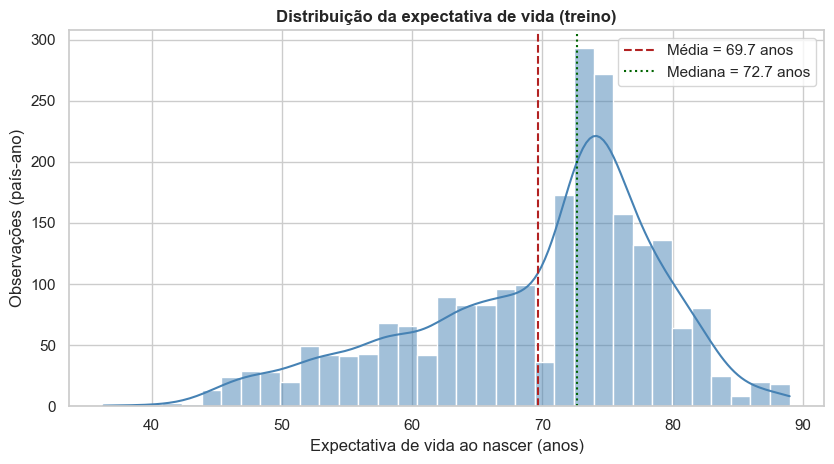

**Interpretação.** O alvo vai de 36.3 a 89.0 anos (desvio-padrão 9.4); a mediana (72.7) fica acima da média (69.7), assimetria -0.75 — há uma cauda de países com valores baixos. Prever sempre a média erra, em média, cerca de 9.4 anos: esse é o **piso de erro** que os modelos precisam superar.

In [9]:
secao("4.2 (c)", "Gráfico 2 — distribuição da variável-alvo (treino)", "#2e7d32")
# Gráfico 2 — distribuição da variável-alvo (treino)
y_ = df_treino["expectativa_vida"]
fig, ax = plt.subplots(figsize=(8.5, 4.8))
sns.histplot(y_, bins=35, kde=True, color="steelblue", ax=ax)
ax.axvline(y_.mean(), color="firebrick", ls="--", label=f"Média = {y_.mean():.1f} anos")
ax.axvline(y_.median(), color="darkgreen", ls=":", label=f"Mediana = {y_.median():.1f} anos")
ax.set_title("Distribuição da expectativa de vida (treino)"); ax.set_xlabel("Expectativa de vida ao nascer (anos)"); ax.set_ylabel("Observações (país-ano)")
ax.legend(); plt.tight_layout(); plt.show()
md(f"**Interpretação.** O alvo vai de {y_.min():.1f} a {y_.max():.1f} anos (desvio-padrão {y_.std():.1f}); a mediana ({y_.median():.1f}) "
   f"{'fica acima' if y_.median() > y_.mean() else 'fica abaixo'} da média ({y_.mean():.1f}), assimetria {y_.skew():+.2f}"
   f"{' — há uma cauda de países com valores baixos' if y_.skew() < -0.3 else ''}. "
   f"Prever sempre a média erra, em média, cerca de {y_.std():.1f} anos: esse é o **piso de erro** que os modelos precisam superar.")

<div style="background:#2e7d32;color:white;padding:8px 14px;border-radius:6px;font-size:16px;margin:6px 0"><b>▶ 4.2 (c)</b> &nbsp;|&nbsp; Gráfico 3 — expectativa de vida por status de desenvolvimento (treino)</div>

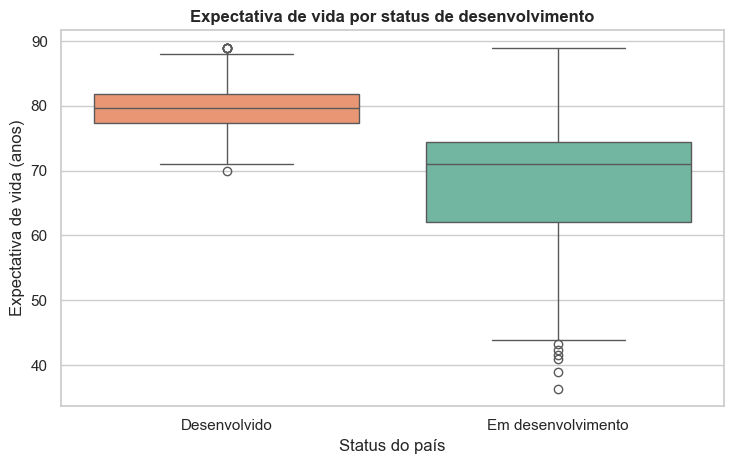

**Interpretação.** Medianas: **Desenvolvido** 79.6 anos; **Em desenvolvimento** 71.1 anos (diferença de 8.5 anos). Há sobreposição entre os grupos, então `status` ajuda mas não resolve sozinho. É associação descritiva, não causal.

In [10]:
secao("4.2 (c)", "Gráfico 3 — expectativa de vida por status de desenvolvimento (treino)", "#2e7d32")
# Gráfico 3 — expectativa de vida por status de desenvolvimento (treino)
d_box = df_treino.assign(status_pt=df_treino["status"].map(STATUS_PT))
fig, ax = plt.subplots(figsize=(7.5, 4.8))
sns.boxplot(data=d_box, x="status_pt", y="expectativa_vida", order=[v for v in STATUS_PT.values() if v in set(d_box["status_pt"])],
            hue="status_pt", palette="Set2", legend=False, ax=ax)
ax.set_title("Expectativa de vida por status de desenvolvimento"); ax.set_xlabel("Status do país"); ax.set_ylabel("Expectativa de vida (anos)")
plt.tight_layout(); plt.show()
med = d_box.groupby("status_pt")["expectativa_vida"].median()
md("**Interpretação.** Medianas: " + "; ".join(f"**{k}** {v:.1f} anos" for k, v in med.items()) +
   f" (diferença de {med.max() - med.min():.1f} anos). Há sobreposição entre os grupos, então `status` ajuda mas não resolve sozinho. É associação descritiva, não causal.")

<div style="background:#2e7d32;color:white;padding:8px 14px;border-radius:6px;font-size:16px;margin:6px 0"><b>▶ 4.2 (c)</b> &nbsp;|&nbsp; Gráficos 4 e 5 — relação das duas variáveis socioeconômicas com o alvo (treino)</div>

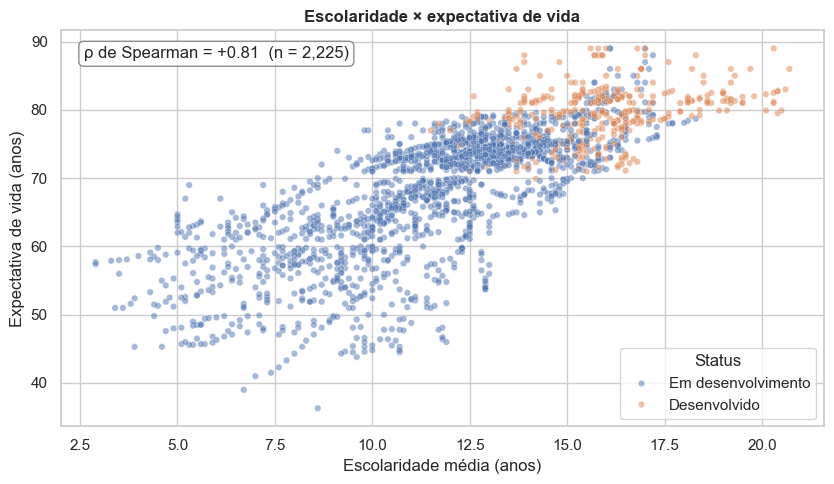

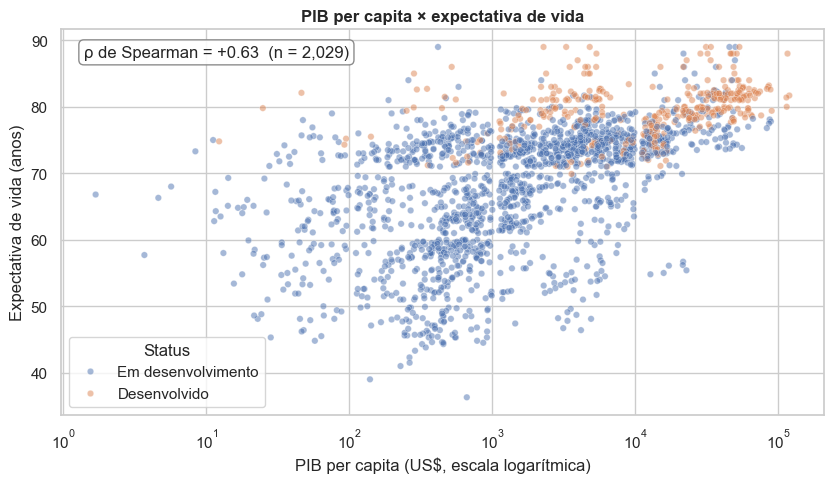

**Interpretação.** Ambas as relações são crescentes (ρ de Spearman = +0.81 para escolaridade e +0.63 para PIB per capita). A escolaridade segue uma tendência quase linear; para o PIB, a escala logarítmica mostra ganhos que **diminuem nos níveis altos de renda** (curva côncava) — relação não linear que favorece modelos de árvores. Pontos em cores diferentes mostram que a associação existe dentro de cada grupo de status. Associação, não causalidade.

In [11]:
secao("4.2 (c)", "Gráficos 4 e 5 — relação das duas variáveis socioeconômicas com o alvo (treino)", "#2e7d32")
# Gráficos 4 e 5 — relação das duas variáveis socioeconômicas com o alvo (treino)
rho_esc = dispersao_alvo("escolaridade_anos", "Escolaridade × expectativa de vida", "Escolaridade média (anos)")
rho_pib = dispersao_alvo("pib_per_capita", "PIB per capita × expectativa de vida", "PIB per capita (US$, escala logarítmica)", log_x=True)
md(f"**Interpretação.** Ambas as relações são crescentes (ρ de Spearman = {rho_esc:+.2f} para escolaridade e {rho_pib:+.2f} para PIB per capita). "
   "A escolaridade segue uma tendência quase linear; para o PIB, a escala logarítmica mostra ganhos que **diminuem nos níveis altos de renda** (curva côncava) — "
   "relação não linear que favorece modelos de árvores. Pontos em cores diferentes mostram que a associação existe dentro de cada grupo de status. Associação, não causalidade.")

<div style="background:#2e7d32;color:white;padding:8px 14px;border-radius:6px;font-size:16px;margin:6px 0"><b>▶ 4.2 (c)</b> &nbsp;|&nbsp; Gráfico 6 — matriz de correlação de Spearman entre variáveis numéricas candidatas (treino)</div>

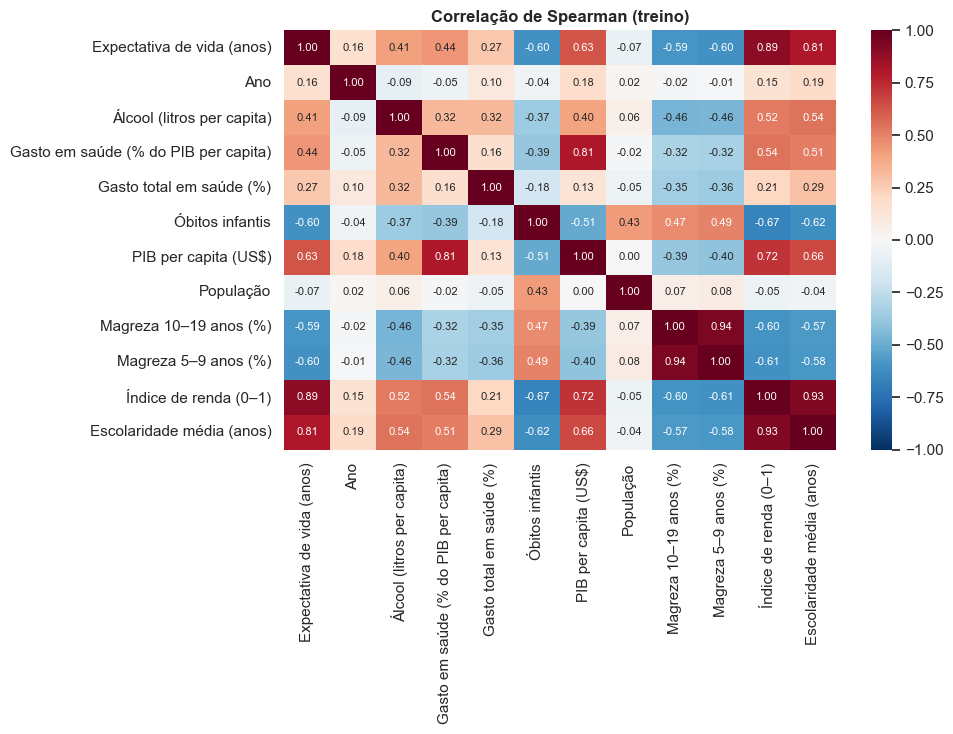

**Interpretação.** O par de preditoras mais correlacionado é **Magreza 5–9 anos (%) × Magreza 10–19 anos (%)** (|ρ| = 0.94). Em particular, `magreza_1_19` e `magreza_5_9` têm ρ = **0.94**: carregam praticamente a mesma informação. Essa redundância (medida **entre preditoras**, sem usar o alvo) sustenta manter apenas uma delas na Seção 4.3. Preditoras muito correlacionadas dividem a importância entre si, o que dificulta a interpretação.

In [12]:
secao("4.2 (c)", "Gráfico 6 — matriz de correlação de Spearman entre variáveis numéricas candidatas (treino)", "#2e7d32")
# Gráfico 6 — matriz de correlação de Spearman entre variáveis numéricas candidatas (treino)
cand_num = ["expectativa_vida", "ano", "alcool", "gasto_saude_pct_pib_pc", "gasto_saude_total_pct", "obitos_infantis",
            "pib_per_capita", "populacao", "magreza_1_19", "magreza_5_9", "indice_renda", "escolaridade_anos"]
corr = df_treino[cand_num].corr(method="spearman")
fig, ax = plt.subplots(figsize=(10, 7.5))
sns.heatmap(corr.rename(index=rot, columns=rot), annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, annot_kws={"size": 8}, ax=ax)
ax.set_title("Correlação de Spearman (treino)"); plt.tight_layout(); plt.show()
RHO_MAG = float(corr.loc["magreza_1_19", "magreza_5_9"])
fe = corr.drop(index="expectativa_vida", columns="expectativa_vida").where(~np.eye(len(corr) - 1, dtype=bool)).abs().stack().sort_values(ascending=False)
md(f"**Interpretação.** O par de preditoras mais correlacionado é **{rot(fe.index[0][0])} × {rot(fe.index[0][1])}** (|ρ| = {fe.iloc[0]:.2f}). "
   f"Em particular, `magreza_1_19` e `magreza_5_9` têm ρ = **{RHO_MAG:.2f}**: carregam praticamente a mesma informação. Essa redundância (medida **entre preditoras**, sem usar o alvo) "
   "sustenta manter apenas uma delas na Seção 4.3. Preditoras muito correlacionadas dividem a importância entre si, o que dificulta a interpretação.")

### <span style="color:#2e7d32">4.2 (d)</span> — Base após o tratamento (dimensões, ausências e duplicidades)  

In [13]:
secao("4.2 (d)", "Confere a base tratada: dimensões, duplicatas e ausências remanescentes", "#2e7d32")
# (d) Confere a base tratada: dimensões, duplicatas e ausências remanescentes
md(f"**Dimensões após o tratamento:** {df_tratado.shape[0]:,} linhas × {df_tratado.shape[1]} colunas · **países:** {df_tratado['pais'].nunique()} · "
   f"**duplicatas (linha):** {int(df_tratado.duplicated().sum())} · **duplicatas (pais, ano):** {int(df_tratado.duplicated(['pais','ano']).sum())} · "
   f"**ausentes no alvo:** {int(df_tratado['expectativa_vida'].isna().sum())}")
assert df_tratado["expectativa_vida"].notna().all() and not df_tratado.duplicated(["pais", "ano"]).any()
aus2 = df_tratado.isna().sum(); aus2 = aus2[aus2 > 0]
if len(aus2):
    t_aus = aus2.rename("n_ausentes").to_frame(); t_aus["% ausentes"] = t_aus["n_ausentes"] / len(df_tratado) * 100
    md("**Ausências remanescentes** (serão imputadas *dentro* do Pipeline, sem olhar o teste; as colunas descartadas na 4.3 aparecem aqui apenas por completude):")
    mostrar(t_aus, fmt={"n_ausentes": "{:,.0f}", "% ausentes": "{:.1f}"})
else:
    md("**Nenhuma ausência remanescente.**")

<div style="background:#2e7d32;color:white;padding:8px 14px;border-radius:6px;font-size:16px;margin:6px 0"><b>▶ 4.2 (d)</b> &nbsp;|&nbsp; Confere a base tratada: dimensões, duplicatas e ausências remanescentes</div>

**Dimensões após o tratamento:** 2,928 linhas × 23 colunas · **países:** 183 · **duplicatas (linha):** 0 · **duplicatas (pais, ano):** 0 · **ausentes no alvo:** 0

**Ausências remanescentes** (serão imputadas *dentro* do Pipeline, sem olhar o teste; as colunas descartadas na 4.3 aparecem aqui apenas por completude):

,n_ausentes,% ausentes
alcool,193,6.6
hepatite_b,553,18.9
imc,32,1.1
polio,19,0.6
gasto_saude_total_pct,226,7.7
difteria,19,0.6
pib_per_capita,443,15.1
populacao,644,22.0
magreza_1_19,32,1.1
magreza_5_9,32,1.1


<a id="s4_3"></a>
<div style="background:#6a1b9a;color:white;padding:18px 22px;border-radius:10px;margin:28px 0 8px 0"><div style="font-size:15px;opacity:.85">SEÇÃO 4.3 &nbsp; <a href="#toc" style="color:#fff;text-decoration:underline">↑ voltar ao índice</a></div><div style="font-size:28px;font-weight:bold;margin:4px 0 8px 0">4.3 — Escolha de variáveis e desenho experimental</div><ul style="margin:0;padding-left:20px;font-size:14px"><li><b>(a)</b> Definição de X e y, variáveis removidas e justificativas </li><li><b>(b)</b> Separação treino/teste e validação cruzada </li><li><b>(c)</b> Métrica principal e métricas auxiliares </li></ul></div>

### <span style="color:#6a1b9a">4.3 (a)</span> — Definição de $X$ e $y$ e variáveis removidas  

As decisões abaixo foram tomadas pela **natureza de cada variável**, **antes de treinar qualquer modelo** e sem olhar métricas. Nenhuma variável foi removida por causa de valores ausentes.

**Este projeto não usa todas as variáveis da base.** Ficaram fora de $X$:

- **Doenças** — `hiv_aids`, `hepatite_b`, `polio`, `difteria`, `sarampo`: decisão de escopo do grupo. O modelo passa a explicar a expectativa de vida por **determinantes socioeconômicos, demográficos e de gasto em saúde**, e não por indicadores específicos de doenças (que são específicos de faixa etária, esparsos — `hepatite_b` tem mais de 15% de ausentes — e, no caso do HIV/AIDS, muito próximos de mortalidade).
- `pais`: identificador; o modelo memorizaria países. É usado só como **grupo** nas partições.
- `mortalidade_adulta`: relação direta com o alvo (quase uma definição alternativa dele) → fonte potencial de *data leakage*.
- `obitos_menores_5`: forte sobreposição conceitual com `obitos_infantis`.
- `imc`: valores implausíveis para uma média nacional (Seção 4.2a).
- `magreza_5_9`: redundante com `magreza_1_19` (correlação medida entre as preditoras, Seção 4.2c).

`obitos_infantis` permanece como indicador de saúde infantil; por ser uma medida de mortalidade, sua forte associação com o alvo é registrada nas limitações.

In [14]:
secao("4.3 (a)", "Define a variável-alvo, os preditores e as exclusões; mostra o papel de cada coluna", "#6a1b9a")
# Define a variável-alvo, os preditores e as exclusões; mostra o papel de cada coluna
ALVO = "expectativa_vida"
VARS_NUM = ["ano", "alcool", "gasto_saude_pct_pib_pc", "gasto_saude_total_pct", "obitos_infantis",
            "pib_per_capita", "populacao", "magreza_1_19", "indice_renda", "escolaridade_anos"]
VARS_CAT = ["status", "regiao"]
FEATURES = VARS_NUM + VARS_CAT
EXCLUIDAS = ["pais", "mortalidade_adulta", "obitos_menores_5", "imc", "magreza_5_9",
             "hiv_aids", "hepatite_b", "polio", "difteria", "sarampo"]

DIC_USO = {
 "expectativa_vida": ("ALVO (y)", "Variável a prever"),
 "pais": ("EXCLUÍDA · usada só como grupo", "Identificador; como preditor o modelo memorizaria países. Agrupa as partições treino/teste e a CV"),
 "mortalidade_adulta": ("EXCLUÍDA", "Relação direta com o alvo; possível data leakage"),
 "obitos_menores_5": ("EXCLUÍDA", "Sobreposição conceitual com `obitos_infantis`"),
 "imc": ("EXCLUÍDA", "Valores implausíveis para média nacional; dado não confiável"),
 "magreza_5_9": ("EXCLUÍDA", f"Redundante com `magreza_1_19` (ρ de Spearman = {RHO_MAG:.2f} no treino)"),
 "hiv_aids": ("EXCLUÍDA (doença)", "Indicador de doença; escopo do projeto não inclui doenças; muito próximo de mortalidade"),
 "hepatite_b": ("EXCLUÍDA (doença)", "Indicador de doença/imunização; escopo do projeto; muitas ausências"),
 "polio": ("EXCLUÍDA (doença)", "Indicador de doença/imunização; escopo do projeto"),
 "difteria": ("EXCLUÍDA (doença)", "Indicador de doença/imunização; escopo do projeto"),
 "sarampo": ("EXCLUÍDA (doença)", "Contagem de casos de doença; escopo do projeto"),
 "ano": ("USADA", "Nível/tendência temporal do painel; o modelo não prevê anos futuros"),
 "status": ("USADA", "Contexto estrutural do país"),
 "regiao": ("USADA", "Contexto geográfico (fonte externa, sem relação direta com o alvo)"),
 "alcool": ("USADA", "Determinante de saúde"),
 "gasto_saude_pct_pib_pc": ("USADA", "Determinante; valores > 100 são plausíveis nesta definição da fonte"),
 "gasto_saude_total_pct": ("USADA", "Determinante de financiamento da saúde"),
 "obitos_infantis": ("USADA", "Indicador de saúde infantil; forte associação com o alvo registrada nas limitações"),
 "pib_per_capita": ("USADA", "Determinante econômico"),
 "populacao": ("USADA", "Escala do país; muitos ausentes (imputados no Pipeline)"),
 "magreza_1_19": ("USADA", "Indicador nutricional de adolescentes"),
 "indice_renda": ("USADA, com ressalva", "Se derivado do IDH, pode conter informação indireta de saúde; risco registrado nas limitações"),
 "escolaridade_anos": ("USADA", "Determinante social"),
}
nao_classificadas = set(df_tratado.columns) - set(FEATURES) - set(EXCLUIDAS) - {ALVO}
assert not nao_classificadas, f"Colunas sem decisão: {nao_classificadas}"
assert set(DIC_USO) == set(df_tratado.columns)

ordem_papel = {"ALVO": 0, "USADA": 1, "EXCLUÍDA": 2}
papel = pd.DataFrame([(v, DIC_USO[v][0], DIC_USO[v][1]) for v in df_tratado.columns], columns=["variável", "utilização", "justificativa"])
papel = papel.sort_values("utilização", key=lambda s: s.str.split().str[0].map(lambda t: ordem_papel.get(t.strip("·"), 3))).reset_index(drop=True)
mostrar(papel)

# Monta X e y (o teste permanece isolado até a Seção 4.7)
X_treino, y_treino, g_treino = df_treino[FEATURES], df_treino[ALVO], df_treino["pais"].values
X_teste,  y_teste            = df_teste[FEATURES],  df_teste[ALVO]     # <- não usado até a Seção 4.7
md(f"`X` = **{len(FEATURES)} variáveis** ({len(VARS_NUM)} numéricas + {len(VARS_CAT)} categóricas) de um total de {df_tratado.shape[1] - 1} colunas preditoras da base · `y = {ALVO}` · "
   f"**X_treino** {X_treino.shape} · **X_teste** {X_teste.shape} · **{len(EXCLUIDAS)} colunas removidas**.")

<div style="background:#6a1b9a;color:white;padding:8px 14px;border-radius:6px;font-size:16px;margin:6px 0"><b>▶ 4.3 (a)</b> &nbsp;|&nbsp; Define a variável-alvo, os preditores e as exclusões; mostra o papel de cada coluna</div>

,variável,utilização,justificativa
0,expectativa_vida,ALVO (y),Variável a prever
1,ano,USADA,Nível/tendência temporal do painel; o modelo não prevê anos futuros
2,status,USADA,Contexto estrutural do país
3,obitos_infantis,USADA,Indicador de saúde infantil; forte associação com o alvo registrada nas limitações
4,gasto_saude_pct_pib_pc,USADA,Determinante; valores > 100 são plausíveis nesta definição da fonte
5,alcool,USADA,Determinante de saúde
6,gasto_saude_total_pct,USADA,Determinante de financiamento da saúde
7,pib_per_capita,USADA,Determinante econômico
8,escolaridade_anos,USADA,Determinante social
9,magreza_1_19,USADA,Indicador nutricional de adolescentes


`X` = **12 variáveis** (10 numéricas + 2 categóricas) de um total de 22 colunas preditoras da base · `y = expectativa_vida` · **X_treino** (2336, 12) · **X_teste** (592, 12) · **10 colunas removidas**.

### <span style="color:#6a1b9a">4.3 (b)</span> — Separação treino/teste e validação cruzada  

| Item | Decisão | Justificativa |
|---|---|---|
| Separação | 80% treino / 20% teste, **por país**, `random_state=42` (feita na Seção 4.2c) | Evita vazamento por país repetido |
| Validação cruzada | **5 folds por grupo (país)** dentro de $\mathcal{D}_{treino}$, atribuição aleatória fixa (`seed=42`) | Cada fold valida em países inéditos; os **mesmos folds** são reutilizados em baseline, Grid Search, Optuna, curva de aprendizado e importância |
| Pré-processamento | `Pipeline`: imputação pela **mediana** (numéricas) e pela moda + *one-hot* (categóricas), ajustados só no treino de cada fold | Mesma lógica para os 3 algoritmos, sem vazamento. Árvores dispensam escalonamento |
| Referência | `DummyRegressor` (média do treino) | Piso: modelo que não supera a média não aprendeu nada |
| **Regra de escolha do modelo final** (fixada **antes** de usar o teste) | (1) melhor RMSE médio de CV entre as 9 configurações; (2) são **empatadas** as que ficam até 1 erro-padrão (dp dos folds da melhor / √5) acima dela; (3) entre as empatadas, menor *gap* $\Delta_\downarrow=\text{RMSE}_{CV}-\text{RMSE}_{treino}$ e, persistindo empate, menor tempo | Regra do 1-erro-padrão: prefere o modelo mais estável quando a diferença não é distinguível do ruído entre folds. Só usa treino/validação |

**Nota sobre CV e tuning.** O teste fica isolado até a 4.7. Grid Search e Optuna usam somente $\mathcal{D}_{treino}$, com os mesmos folds. Como os mesmos folds orientam a busca e a escolha, o desempenho de CV pós-tuning pode ser levemente otimista; a estimativa final de generalização vem **somente** do teste. Não foi usada CV aninhada (custo computacional).

In [15]:
secao("4.3 (b)", "Validação cruzada por país (mesmos folds para todos os modelos) e pipeline de preparação", "#6a1b9a")
# Validação cruzada por país (mesmos folds para todos os modelos) e pipeline de preparação
K_FOLDS = 5
def criar_folds(grupos, k=K_FOLDS, seed=SEED):
    """Atribui países a folds de forma aleatória porém fixa; retorna lista (idx_treino, idx_val)."""
    rng = np.random.RandomState(seed)
    paises = np.array(sorted(pd.unique(grupos))); rng.shuffle(paises)
    fold_do_pais = {p: i % k for i, p in enumerate(paises)}
    f = np.array([fold_do_pais[g] for g in grupos])
    return [(np.where(f != i)[0], np.where(f == i)[0]) for i in range(k)]

FOLDS = criar_folds(g_treino)
assert all(set(g_treino[a]).isdisjoint(g_treino[b]) for a, b in FOLDS)
SCORING = {"rmse": "neg_root_mean_squared_error", "mae": "neg_mean_absolute_error", "r2": "r2"}
PRINCIPAL = "neg_root_mean_squared_error"

def montar_preprocessador():
    pre = ColumnTransformer([
        ("num", SimpleImputer(strategy="median"), VARS_NUM),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("oh", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), VARS_CAT),
    ], verbose_feature_names_out=False)
    return pre.set_output(transform="pandas")

def montar_pipeline(estimador):
    return Pipeline([("prep", montar_preprocessador()), ("model", estimador)])

def metricas(y, p):
    return {"RMSE": float(np.sqrt(mean_squared_error(y, p))), "MAE": float(mean_absolute_error(y, p)), "R2": float(r2_score(y, p))}

_chk = montar_preprocessador().fit(X_treino).transform(X_treino)
assert not _chk.isna().any().any() and y_treino.notna().all()      # o pipeline não deixa NaN em X

md("*A separação treino/teste foi **executada na Seção 4.2(c)** (antes da EDA, para que a EDA nunca enxergasse o teste); aqui está o resumo e o protocolo formal.*")
resumo_split = pd.DataFrame({"conjunto": ["D_treino (80%)", "D_teste (20%, isolado)"], "linhas": [len(df_treino), len(df_teste)],
                             "países": [df_treino["pais"].nunique(), df_teste["pais"].nunique()],
                             "% das linhas": [len(df_treino) / len(df_tratado) * 100, len(df_teste) / len(df_tratado) * 100]})
mostrar(resumo_split.set_index("conjunto"), fmt={"linhas": "{:,.0f}", "países": "{:,.0f}", "% das linhas": "{:.1f}"})
md(f"**Validação cruzada dentro de D_treino:** {K_FOLDS} folds por país (tamanhos abaixo).")
tam = pd.DataFrame({"fold": range(1, K_FOLDS + 1), "linhas treino": [len(a) for a, _ in FOLDS], "linhas validação": [len(b) for _, b in FOLDS],
                    "países validação": [len(set(g_treino[b])) for _, b in FOLDS]})
mostrar(tam, fmt={c: "{:,.0f}" for c in tam.columns})

<div style="background:#6a1b9a;color:white;padding:8px 14px;border-radius:6px;font-size:16px;margin:6px 0"><b>▶ 4.3 (b)</b> &nbsp;|&nbsp; Validação cruzada por país (mesmos folds para todos os modelos) e pipeline de preparação</div>

*A separação treino/teste foi **executada na Seção 4.2(c)** (antes da EDA, para que a EDA nunca enxergasse o teste); aqui está o resumo e o protocolo formal.*

,linhas,países,% das linhas
conjunto,,,
D_treino (80%),"2,336",146,79.8
"D_teste (20%, isolado)",592,37,20.2


**Validação cruzada dentro de D_treino:** 5 folds por país (tamanhos abaixo).

,fold,linhas treino,linhas validação,países validação
0,1,"1,856",480,30
1,2,"1,872",464,29
2,3,"1,872",464,29
3,4,"1,872",464,29
4,5,"1,872",464,29


### <span style="color:#6a1b9a">4.3 (c)</span> — Métrica principal e métricas auxiliares  

| Métrica | Papel | Como interpretar |
|---|---|---|
| **RMSE** (anos) | **Principal** — critério de Grid Search, Optuna e escolha do modelo | Erro típico em anos, com peso maior para erros grandes. Menor é melhor |
| **MAE** (anos) | Auxiliar | Erro absoluto médio, robusto a extremos; ≈ erro esperado numa previsão comum |
| **R²** | Auxiliar | Fração da variância do alvo explicada; 0 = tão bom quanto prever a média |
| Gap $\Delta_\downarrow$ | Diagnóstico | RMSE de CV − RMSE de treino: gap alto sugere sobreajuste (lido junto da curva de aprendizado e do desvio entre folds) |

<a id="s4_4"></a>
<div style="background:#ef6c00;color:white;padding:18px 22px;border-radius:10px;margin:28px 0 8px 0"><div style="font-size:15px;opacity:.85">SEÇÃO 4.4 &nbsp; <a href="#toc" style="color:#fff;text-decoration:underline">↑ voltar ao índice</a></div><div style="font-size:28px;font-weight:bold;margin:4px 0 8px 0">4.4 — Implementação dos três modelos de referência (baseline)</div><ul style="margin:0;padding-left:20px;font-size:14px"><li><b>(a)</b> Random Forest de referência </li><li><b>(b)</b> XGBoost de referência </li><li><b>(c)</b> LightGBM de referência </li><li><b>(d)</b> Tabela única, interpretação e sinais de over/underfitting </li></ul></div>

Primeira versão **comparável** dos três algoritmos, **antes do tuning**: mesmo número de árvores (150) e demais hiperparâmetros nos valores usuais de cada biblioteca. O objetivo é um *baseline*, não o melhor conjunto de hiperparâmetros. A função `avaliar_cv` é usada por **todas** as configurações deste notebook (mesmos folds, mesma métrica). "Treino" = RMSE médio nos folds de treino; "CV" = RMSE médio nos folds de validação.

In [16]:
secao("4.4", "Definições comuns aos três modelos (construtor, hiperparâmetros-base e função de avaliação por ", "#ef6c00")
# Definições comuns aos três modelos (construtor, hiperparâmetros-base e função de avaliação por CV)
MODELOS = ["Random Forest", "XGBoost", "LightGBM"]
N_ARVORES_BASE = 150
PARAMS_EXIBIR = {
 "Random Forest": ["n_estimators", "max_depth", "min_samples_leaf", "max_features", "random_state"],
 "XGBoost":       ["n_estimators", "learning_rate", "max_depth", "min_child_weight", "subsample", "colsample_bytree", "reg_lambda", "random_state"],
 "LightGBM":      ["n_estimators", "learning_rate", "num_leaves", "min_child_samples", "subsample", "colsample_bytree", "reg_lambda", "random_state"],
}
def construir(nome, params=None):
    p = dict(params or {})
    if nome == "Random Forest":
        base = dict(n_estimators=N_ARVORES_BASE, max_depth=None, min_samples_leaf=1, max_features=1.0, random_state=SEED, n_jobs=1); base.update(p); return RandomForestRegressor(**base)
    if nome == "XGBoost":
        base = dict(n_estimators=N_ARVORES_BASE, learning_rate=0.1, max_depth=6, min_child_weight=1, subsample=1.0, colsample_bytree=1.0, reg_lambda=1.0,
                    random_state=SEED, n_jobs=1, tree_method="hist"); base.update(p); return XGBRegressor(**base)
    if nome == "LightGBM":
        base = dict(n_estimators=N_ARVORES_BASE, learning_rate=0.1, num_leaves=31, min_child_samples=20, subsample=1.0, colsample_bytree=1.0, reg_lambda=0.0,
                    subsample_freq=1, random_state=SEED, n_jobs=1, verbose=-1); base.update(p); return LGBMRegressor(**base)
    raise ValueError(nome)

def fmt_val(v): return str(round(v, 4)) if isinstance(v, float) else str(v)
def fmt_params(d): return ", ".join(f"{k}={fmt_val(v)}" for k, v in d.items()) if d else "padrão do baseline"
def params_efetivos(nome, params=None):
    gp = construir(nome, params).get_params(); return {k: gp[k] for k in PARAMS_EXIBIR[nome]}

def avaliar_cv(estimador, modelo, estrategia, params=None, tempo_busca=0.0, n_ajustes=K_FOLDS):
    # Mesma régua para todas as configurações: mesmos folds, mesmas métricas.
    r = cross_validate(montar_pipeline(estimador), X_treino, y_treino, cv=FOLDS, scoring=SCORING, return_train_score=True, n_jobs=N_JOBS)
    cv, tr = -r["test_rmse"], -r["train_rmse"]
    return {"modelo": modelo, "estratégia": estrategia,
            "RMSE treino": tr.mean(), "RMSE CV (média)": cv.mean(), "RMSE CV (dp)": cv.std(ddof=1),
            "gap (CV−treino)": cv.mean() - tr.mean(), "gap relativo": (cv.mean() - tr.mean()) / cv.mean(),
            "MAE CV": -r["test_mae"].mean(), "R² CV": r["test_r2"].mean(), "R² treino": r["train_r2"].mean(),
            "tempo fit/fold (s)": r["fit_time"].mean(), "tempo busca (s)": float(tempo_busca), "nº ajustes": int(n_ajustes),
            "params": dict(params or {}), "_cv_folds": cv, "_tr_folds": tr}

def rodar_baseline(nome):
    t0 = time.perf_counter()
    r_ = avaliar_cv(construir(nome), nome, "Baseline", params={}); r_["hiperparâmetros"] = fmt_params(params_efetivos(nome))
    RESULTADOS.append(r_)
    md(f"**Hiperparâmetros do baseline — {nome}**")
    mostrar(pd.DataFrame([{"hiperparâmetro": k, "valor": fmt_val(v)} for k, v in params_efetivos(nome).items()]))
    md(f"RMSE treino **{r_['RMSE treino']:.3f}** · RMSE validação (CV) **{r_['RMSE CV (média)']:.3f} ± {r_['RMSE CV (dp)']:.3f}** · tempo por fold {r_['tempo fit/fold (s)']:.2f}s")
    print(f"⏱ {nome}: {time.perf_counter() - t0:.1f}s")

RESULTADOS = []
ref = avaliar_cv(DummyRegressor(strategy="mean"), "Referência (média)", "Dummy")      # piso: prever sempre a média

<div style="background:#ef6c00;color:white;padding:8px 14px;border-radius:6px;font-size:16px;margin:6px 0"><b>▶ 4.4</b> &nbsp;|&nbsp; Definições comuns aos três modelos (construtor, hiperparâmetros-base e função de avaliação por </div>

### <span style="color:#ef6c00">4.4 (a)</span> — Random Forest de referência  

In [17]:
secao("4.4 (a)", "Baseline — Random Forest (hiperparâmetros registrados abaixo)", "#ef6c00")
# Baseline — Random Forest (hiperparâmetros registrados abaixo)
rodar_baseline("Random Forest")

<div style="background:#ef6c00;color:white;padding:8px 14px;border-radius:6px;font-size:16px;margin:6px 0"><b>▶ 4.4 (a)</b> &nbsp;|&nbsp; Baseline — Random Forest (hiperparâmetros registrados abaixo)</div>

**Hiperparâmetros do baseline — Random Forest**

,hiperparâmetro,valor
0,n_estimators,150
1,max_depth,None
2,min_samples_leaf,1
3,max_features,1.0
4,random_state,42


RMSE treino **0.793** · RMSE validação (CV) **4.536 ± 0.535** · tempo por fold 0.86s

⏱ Random Forest: 1.0s


### <span style="color:#ef6c00">4.4 (b)</span> — XGBoost de referência  

In [18]:
secao("4.4 (b)", "Baseline — XGBoost (mesmo protocolo: mesmos folds, mesma métrica)", "#ef6c00")
# Baseline — XGBoost (mesmo protocolo: mesmos folds, mesma métrica)
rodar_baseline("XGBoost")

<div style="background:#ef6c00;color:white;padding:8px 14px;border-radius:6px;font-size:16px;margin:6px 0"><b>▶ 4.4 (b)</b> &nbsp;|&nbsp; Baseline — XGBoost (mesmo protocolo: mesmos folds, mesma métrica)</div>

**Hiperparâmetros do baseline — XGBoost**

,hiperparâmetro,valor
0,n_estimators,150
1,learning_rate,0.1
2,max_depth,6
3,min_child_weight,1
4,subsample,1.0
5,colsample_bytree,1.0
6,reg_lambda,1.0
7,random_state,42


RMSE treino **0.730** · RMSE validação (CV) **4.236 ± 0.308** · tempo por fold 0.15s

⏱ XGBoost: 0.2s


### <span style="color:#ef6c00">4.4 (c)</span> — LightGBM de referência  

In [19]:
secao("4.4 (c)", "Baseline — LightGBM (mesmo protocolo: mesmos folds, mesma métrica)", "#ef6c00")
# Baseline — LightGBM (mesmo protocolo: mesmos folds, mesma métrica)
rodar_baseline("LightGBM")

<div style="background:#ef6c00;color:white;padding:8px 14px;border-radius:6px;font-size:16px;margin:6px 0"><b>▶ 4.4 (c)</b> &nbsp;|&nbsp; Baseline — LightGBM (mesmo protocolo: mesmos folds, mesma métrica)</div>

**Hiperparâmetros do baseline — LightGBM**

,hiperparâmetro,valor
0,n_estimators,150
1,learning_rate,0.1
2,num_leaves,31
3,min_child_samples,20
4,subsample,1.0
5,colsample_bytree,1.0
6,reg_lambda,0.0
7,random_state,42


RMSE treino **0.858** · RMSE validação (CV) **4.402 ± 0.505** · tempo por fold 0.08s

⏱ LightGBM: 0.2s


### <span style="color:#ef6c00">4.4 (d)</span> — Tabela única dos baselines, interpretação e sinais de overfitting/underfitting  

<div style="background:#ef6c00;color:white;padding:8px 14px;border-radius:6px;font-size:16px;margin:6px 0"><b>▶ 4.4 (d)</b> &nbsp;|&nbsp; Tabela única do baseline: modelo, treino, média e desvio da CV, tempo de treinamento</div>

**Tabela de baseline** (RMSE em anos; a primeira linha é a referência que prevê a média)

,RMSE treino,RMSE CV (média),RMSE CV (dp),gap (CV−treino),gap relativo,R² CV,tempo fit/fold (s)
modelo,,,,,,,
Referência (prever a média),9.422,9.395,1.090,-0.027,-0.003,-0.008,0.012
Random Forest,0.793,4.536,0.535,3.743,0.825,0.755,0.859
XGBoost,0.730,4.236,0.308,3.506,0.828,0.789,0.154
LightGBM,0.858,4.402,0.505,3.544,0.805,0.770,0.076


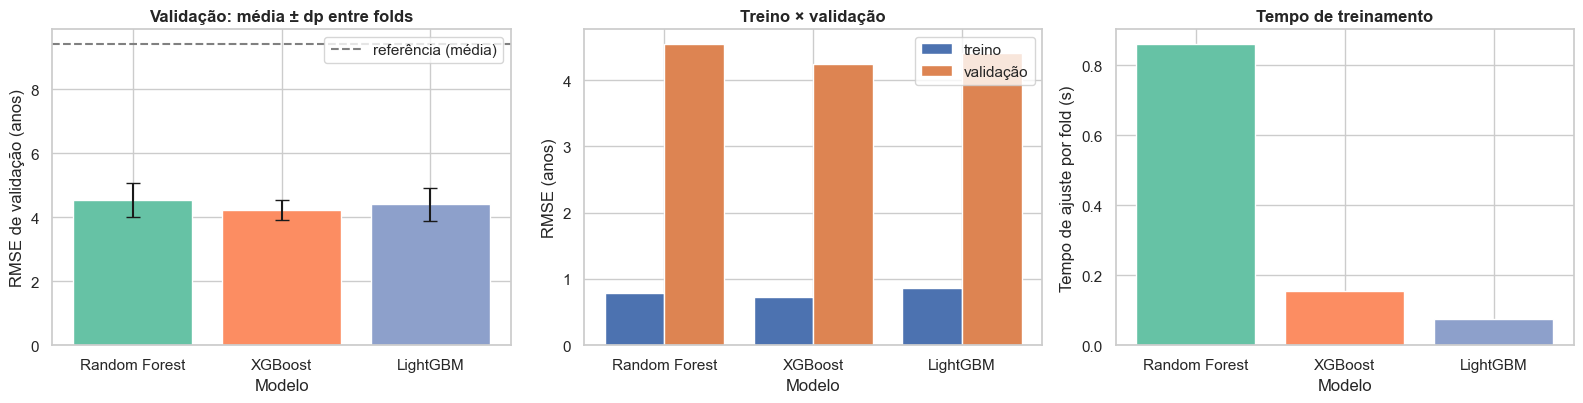

**Interpretação do baseline.**  
- **Random Forest**: CV 4.536 ± 0.535 anos (treino 0.793; R² CV 0.755); gap relativo ≥ 50% → possível overfitting.  
- **XGBoost**: CV 4.236 ± 0.308 anos (treino 0.730; R² CV 0.789); gap relativo ≥ 50% → possível overfitting.  
- **LightGBM**: CV 4.402 ± 0.505 anos (treino 0.858; R² CV 0.770); gap relativo ≥ 50% → possível overfitting.

Melhor baseline por RMSE de CV: **XGBoost**. Todos superam a referência da média (9.395 anos), logo **não há sinal de underfitting grave**. O gap entre treino e validação é o principal sinal de **overfitting**: árvores profundas ajustam muito bem o treino, e o erro em países inéditos é maior. Diferenças menores que o desvio entre folds não permitem afirmar superioridade. Limiares do diagnóstico (25% / 50%) são heurísticas pedagógicas.

In [20]:
secao("4.4 (d)", "Tabela única do baseline: modelo, treino, média e desvio da CV, tempo de treinamento", "#ef6c00")
# Tabela única do baseline: modelo, treino, média e desvio da CV, tempo de treinamento
COLS_BASE = ["modelo", "RMSE treino", "RMSE CV (média)", "RMSE CV (dp)", "gap (CV−treino)", "gap relativo", "R² CV", "tempo fit/fold (s)"]
tab_base = pd.concat([pd.DataFrame([{**ref, "modelo": "Referência (prever a média)"}])[COLS_BASE], pd.DataFrame(RESULTADOS)[COLS_BASE]], ignore_index=True)
md("**Tabela de baseline** (RMSE em anos; a primeira linha é a referência que prevê a média)")
mostrar(tab_base.set_index("modelo"), fmt={c: "{:.3f}" for c in COLS_BASE[1:]})

def diagnostico(r, ref_rmse=ref["RMSE CV (média)"]):
    sinais = []
    if r["gap relativo"] >= 0.50: sinais.append("gap relativo ≥ 50% → possível overfitting")
    elif r["gap relativo"] >= 0.25: sinais.append("gap moderado (25–50%)")
    if r["R² CV"] < 0.50 or r["RMSE CV (média)"] > 0.80 * ref_rmse: sinais.append("pouco ganho sobre a média → possível underfitting")
    if r["RMSE CV (dp)"] / r["RMSE CV (média)"] > 0.20: sinais.append("alta variação entre folds")
    return "; ".join(sinais) if sinais else "sem sinal relevante (generalização consistente)"

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2)); cores = sns.color_palette("Set2", 3); x = np.arange(3)
axes[0].bar(x, [r["RMSE CV (média)"] for r in RESULTADOS], yerr=[r["RMSE CV (dp)"] for r in RESULTADOS], capsize=5, color=cores)
axes[0].axhline(ref["RMSE CV (média)"], ls="--", c="gray", label="referência (média)"); axes[0].legend()
axes[0].set_xticks(x, MODELOS); axes[0].set_ylabel("RMSE de validação (anos)"); axes[0].set_title("Validação: média ± dp entre folds")
axes[1].bar(x - .2, [r["RMSE treino"] for r in RESULTADOS], .4, label="treino"); axes[1].bar(x + .2, [r["RMSE CV (média)"] for r in RESULTADOS], .4, label="validação")
axes[1].set_xticks(x, MODELOS); axes[1].set_ylabel("RMSE (anos)"); axes[1].set_title("Treino × validação"); axes[1].legend()
axes[2].bar(x, [r["tempo fit/fold (s)"] for r in RESULTADOS], color=cores); axes[2].set_xticks(x, MODELOS); axes[2].set_ylabel("Tempo de ajuste por fold (s)"); axes[2].set_title("Tempo de treinamento")
for a in axes: a.set_xlabel("Modelo")
plt.tight_layout(); plt.show()

melhor_base = min(RESULTADOS, key=lambda r: r["RMSE CV (média)"])
md("**Interpretação do baseline.**  \n" + "  \n".join(
   f"- **{r['modelo']}**: CV {r['RMSE CV (média)']:.3f} ± {r['RMSE CV (dp)']:.3f} anos (treino {r['RMSE treino']:.3f}; R² CV {r['R² CV']:.3f}); {diagnostico(r)}." for r in RESULTADOS) +
   f"\n\nMelhor baseline por RMSE de CV: **{melhor_base['modelo']}**. Todos superam a referência da média ({ref['RMSE CV (média)']:.3f} anos), logo **não há sinal de underfitting grave**. "
   "O gap entre treino e validação é o principal sinal de **overfitting**: árvores profundas ajustam muito bem o treino, e o erro em países inéditos é maior. "
   "Diferenças menores que o desvio entre folds não permitem afirmar superioridade. Limiares do diagnóstico (25% / 50%) são heurísticas pedagógicas.")

<a id="s4_5"></a>
<div style="background:#c62828;color:white;padding:18px 22px;border-radius:10px;margin:28px 0 8px 0"><div style="font-size:15px;opacity:.85">SEÇÃO 4.5 &nbsp; <a href="#toc" style="color:#fff;text-decoration:underline">↑ voltar ao índice</a></div><div style="font-size:28px;font-weight:bold;margin:4px 0 8px 0">4.5 — Tuning com Grid Search e Optuna</div><ul style="margin:0;padding-left:20px;font-size:14px"><li><b>(a)</b> Grid Search </li><li><b>(b)</b> Optuna </li><li><b>(c)</b> Comparação Grid Search × Optuna </li></ul></div>

Todo o tuning ocorre **exclusivamente em $\mathcal{D}_{treino}$**, com o mesmo pipeline, os mesmos `FOLDS` e a mesma métrica (RMSE). O problema geral é
$$\theta^\star=\arg\min_{\theta\in\Theta}\ \frac1K\sum_{k=1}^{K}\text{RMSE}_k(\theta),\qquad K=5.$$

### <span style="color:#c62828">4.5 (a)</span> — Grid Search  

`GridSearchCV` com grades que exploram **número de árvores, complexidade/profundidade e taxa de aprendizado**, em tamanho moderado para manter o tempo baixo.

In [21]:
secao("4.5 (a)", "Grid Search nos três modelos (apenas treino, mesmos FOLDS)", "#c62828")
# (a) Grid Search nos três modelos (apenas treino, mesmos FOLDS)
GRADES = {
 "Random Forest": {"n_estimators": [100, 200], "max_depth": [8, None], "min_samples_leaf": [1, 3, 5], "max_features": [0.5, 1.0]},
 "XGBoost":       {"n_estimators": [100, 200], "learning_rate": [0.05, 0.1], "max_depth": [3, 5, 7], "subsample": [0.8, 1.0]},
 "LightGBM":      {"n_estimators": [100, 200], "learning_rate": [0.05, 0.1], "num_leaves": [15, 31, 63], "min_child_samples": [10, 30]},
}
GRID = {}
for nome in MODELOS:
    grade = {f"model__{k}": v for k, v in GRADES[nome].items()}      # model__ aponta para o estimador dentro do Pipeline
    gs = GridSearchCV(montar_pipeline(construir(nome)), grade, cv=FOLDS, scoring=PRINCIPAL, refit=False, return_train_score=True, n_jobs=N_JOBS)
    t0 = time.perf_counter(); gs.fit(X_treino, y_treino); dt = time.perf_counter() - t0
    melhores = {k.replace("model__", ""): v for k, v in gs.best_params_.items()}
    n_comb = len(gs.cv_results_["params"])
    GRID[nome] = {"gs": gs, "params": melhores, "tempo": dt, "n_comb": n_comb}
    RESULTADOS.append(avaliar_cv(construir(nome, melhores), nome, "Grid Search", params=melhores, tempo_busca=dt, n_ajustes=n_comb * K_FOLDS))
    RESULTADOS[-1]["hiperparâmetros"] = fmt_params(params_efetivos(nome, melhores))
    print(f"{nome}: {n_comb} combinações · melhor RMSE CV {-gs.best_score_:.4f} · {dt:.1f}s")

md("**Resumo do Grid Search**")
mostrar(pd.DataFrame([{"modelo": n, "combinações": GRID[n]["n_comb"], "ajustes (combinações × 5 folds)": GRID[n]["n_comb"] * K_FOLDS,
                       "melhor RMSE CV": -GRID[n]["gs"].best_score_, "pior RMSE CV da grade": (-GRID[n]["gs"].cv_results_["mean_test_score"]).max(),
                       "tempo (s)": GRID[n]["tempo"]} for n in MODELOS]).set_index("modelo"),
        fmt={"combinações": "{:.0f}", "ajustes (combinações × 5 folds)": "{:.0f}", "melhor RMSE CV": "{:.3f}", "pior RMSE CV da grade": "{:.3f}", "tempo (s)": "{:.1f}"})
md("**Melhores hiperparâmetros (Grid Search)**")
mostrar(pd.DataFrame([{"modelo": n, "hiperparâmetro": k, "valor": fmt_val(v)} for n in MODELOS for k, v in GRID[n]["params"].items()]))

<div style="background:#c62828;color:white;padding:8px 14px;border-radius:6px;font-size:16px;margin:6px 0"><b>▶ 4.5 (a)</b> &nbsp;|&nbsp; Grid Search nos três modelos (apenas treino, mesmos FOLDS)</div>

Random Forest: 24 combinações · melhor RMSE CV 4.2330 · 13.4s
XGBoost: 24 combinações · melhor RMSE CV 4.2536 · 4.4s
LightGBM: 24 combinações · melhor RMSE CV 4.3204 · 2.6s


**Resumo do Grid Search**

,combinações,ajustes (combinações × 5 folds),melhor RMSE CV,pior RMSE CV da grade,tempo (s)
modelo,,,,,
Random Forest,24,120,4.233,4.569,13.4
XGBoost,24,120,4.254,4.505,4.4
LightGBM,24,120,4.320,4.677,2.6


**Melhores hiperparâmetros (Grid Search)**

,modelo,hiperparâmetro,valor
0,Random Forest,max_depth,None
1,Random Forest,max_features,0.5
2,Random Forest,min_samples_leaf,3
3,Random Forest,n_estimators,100
4,XGBoost,learning_rate,0.05
5,XGBoost,max_depth,5
6,XGBoost,n_estimators,200
7,XGBoost,subsample,0.8
8,LightGBM,learning_rate,0.05
9,LightGBM,min_child_samples,30


<div style="background:#c62828;color:white;padding:8px 14px;border-radius:6px;font-size:16px;margin:6px 0"><b>▶ 4.5 (a)</b> &nbsp;|&nbsp; Gráfico: RMSE de treino e validação de cada combinação do Grid Search (ordenadas da melhor para</div>

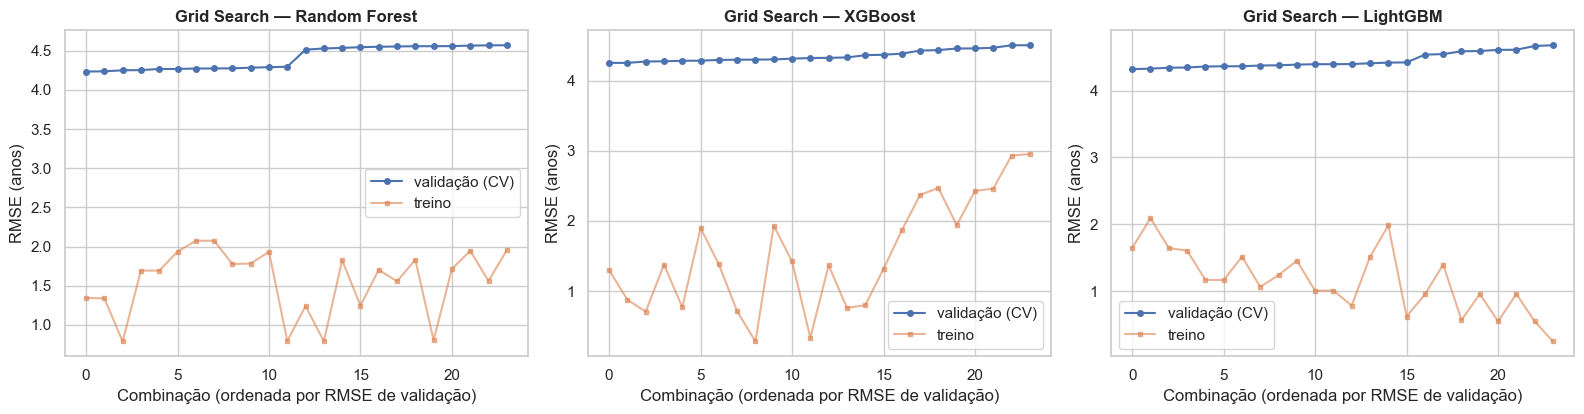

**Interpretação.** Amplitude entre a pior e a melhor combinação (RMSE de CV): Random Forest: 0.336 anos; XGBoost: 0.252 anos; LightGBM: 0.357 anos. Amplitude pequena indica modelo pouco sensível aos hiperparâmetros testados; a distância entre as curvas de treino e validação mostra o nível de sobreajuste em cada região da grade. Hiperparâmetros cujo melhor valor está na **borda** da grade (a grade poderia ser estendida — limitação): Random Forest.n_estimators=100, Random Forest.max_depth=None, Random Forest.max_features=0.5, XGBoost.n_estimators=200, XGBoost.learning_rate=0.05, XGBoost.subsample=0.8, LightGBM.n_estimators=200, LightGBM.learning_rate=0.05, LightGBM.num_leaves=15, LightGBM.min_child_samples=30.

In [22]:
secao("4.5 (a)", "Gráfico: RMSE de treino e validação de cada combinação do Grid Search (ordenadas da melhor para", "#c62828")
# Gráfico: RMSE de treino e validação de cada combinação do Grid Search (ordenadas da melhor para a pior)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))
for ax, nome in zip(axes, MODELOS):
    cvr = pd.DataFrame(GRID[nome]["gs"].cv_results_)
    rm = -cvr["mean_test_score"].values; ordem = np.argsort(rm)
    ax.plot(rm[ordem], "o-", ms=4, label="validação (CV)"); ax.plot(-cvr["mean_train_score"].values[ordem], "s-", ms=3, alpha=.6, label="treino")
    ax.set_title(f"Grid Search — {nome}"); ax.set_xlabel("Combinação (ordenada por RMSE de validação)"); ax.set_ylabel("RMSE (anos)"); ax.legend()
plt.tight_layout(); plt.show()
amp = {n: (-GRID[n]["gs"].cv_results_["mean_test_score"]).max() - (-GRID[n]["gs"].best_score_) for n in MODELOS}
borda = [f"{n}.{k}={fmt_val(GRID[n]['params'][k])}" for n in MODELOS for k, v in GRADES[n].items() if len(v) > 1 and GRID[n]["params"][k] in (v[0], v[-1])]
md("**Interpretação.** Amplitude entre a pior e a melhor combinação (RMSE de CV): " + "; ".join(f"{n}: {v:.3f} anos" for n, v in amp.items()) +
   ". Amplitude pequena indica modelo pouco sensível aos hiperparâmetros testados; a distância entre as curvas de treino e validação mostra o nível de sobreajuste em cada região da grade. "
   "Hiperparâmetros cujo melhor valor está na **borda** da grade (a grade poderia ser estendida — limitação): " + (", ".join(borda) if borda else "nenhum") + ".")

### <span style="color:#c62828">4.5 (b)</span> — Optuna  

Otimização bayesiana (TPE, `seed=42`) com **a mesma métrica (RMSE)**, os **mesmos `FOLDS`** e somente $\mathcal{D}_{treino}$. Cada *trial* treina o pipeline completo nos 5 folds e devolve o RMSE médio de validação (a minimizar). Os espaços de busca são **mais amplos e contínuos** que as grades, com **20 trials por modelo** (mínimo exigido pelo enunciado).

In [23]:
secao("4.5 (b)", "Optuna: espaço de busca, função objetivo (RMSE médio de CV) e execução — 20 trials por modelo", "#c62828")
# (b) Optuna: espaço de busca, função objetivo (RMSE médio de CV) e execução — 20 trials por modelo
N_TRIALS = 20
def sugerir(nome, t):
    if nome == "Random Forest":
        return dict(n_estimators=t.suggest_int("n_estimators", 100, 300, step=50), max_depth=t.suggest_int("max_depth", 4, 20),
                    min_samples_leaf=t.suggest_int("min_samples_leaf", 1, 8), max_features=t.suggest_float("max_features", 0.4, 1.0))
    if nome == "XGBoost":
        return dict(n_estimators=t.suggest_int("n_estimators", 100, 300, step=50), learning_rate=t.suggest_float("learning_rate", 0.02, 0.3, log=True),
                    max_depth=t.suggest_int("max_depth", 2, 8), subsample=t.suggest_float("subsample", 0.6, 1.0),
                    colsample_bytree=t.suggest_float("colsample_bytree", 0.6, 1.0), min_child_weight=t.suggest_int("min_child_weight", 1, 8),
                    reg_lambda=t.suggest_float("reg_lambda", 1e-2, 10.0, log=True))
    if nome == "LightGBM":
        return dict(n_estimators=t.suggest_int("n_estimators", 100, 300, step=50), learning_rate=t.suggest_float("learning_rate", 0.02, 0.3, log=True),
                    num_leaves=t.suggest_int("num_leaves", 8, 64), min_child_samples=t.suggest_int("min_child_samples", 5, 40),
                    subsample=t.suggest_float("subsample", 0.6, 1.0), colsample_bytree=t.suggest_float("colsample_bytree", 0.6, 1.0),
                    reg_lambda=t.suggest_float("reg_lambda", 1e-2, 10.0, log=True))

def criar_objetivo(nome):
    def objetivo(trial):
        pipe = montar_pipeline(construir(nome, sugerir(nome, trial)))
        r = cross_validate(pipe, X_treino, y_treino, cv=FOLDS, scoring=PRINCIPAL, n_jobs=N_JOBS)
        return float(-r["test_score"].mean())
    return objetivo

def progresso(estudo, trial):
    if (trial.number + 1) % 5 == 0: print(f"   trial {trial.number + 1}/{N_TRIALS} · melhor RMSE até agora {estudo.best_value:.4f}")

OPT = {}
for nome in MODELOS:
    print(f"Optuna — {nome}")
    estudo = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED, n_startup_trials=8), study_name=nome)
    t0 = time.perf_counter(); estudo.optimize(criar_objetivo(nome), n_trials=N_TRIALS, callbacks=[progresso]); dt = time.perf_counter() - t0
    OPT[nome] = {"estudo": estudo, "params": dict(estudo.best_params), "tempo": dt}
    RESULTADOS.append(avaliar_cv(construir(nome, estudo.best_params), nome, "Optuna", params=dict(estudo.best_params), tempo_busca=dt, n_ajustes=N_TRIALS * K_FOLDS))
    RESULTADOS[-1]["hiperparâmetros"] = fmt_params(params_efetivos(nome, estudo.best_params))
    print(f"   → {len(estudo.trials)} trials · melhor RMSE CV {estudo.best_value:.4f} · {dt:.1f}s")

md("**Resumo do Optuna**")
mostrar(pd.DataFrame([{"modelo": n, "trials": len(OPT[n]["estudo"].trials), "melhor trial (nº)": OPT[n]["estudo"].best_trial.number + 1,
                       "melhor RMSE CV": OPT[n]["estudo"].best_value, "tempo (s)": OPT[n]["tempo"]} for n in MODELOS]).set_index("modelo"),
        fmt={"trials": "{:.0f}", "melhor trial (nº)": "{:.0f}", "melhor RMSE CV": "{:.3f}", "tempo (s)": "{:.1f}"})
md("**Melhores hiperparâmetros (Optuna)**")
mostrar(pd.DataFrame([{"modelo": n, "hiperparâmetro": k, "valor": fmt_val(v)} for n in MODELOS for k, v in OPT[n]["params"].items()]))

<div style="background:#c62828;color:white;padding:8px 14px;border-radius:6px;font-size:16px;margin:6px 0"><b>▶ 4.5 (b)</b> &nbsp;|&nbsp; Optuna: espaço de busca, função objetivo (RMSE médio de CV) e execução — 20 trials por modelo</div>

Optuna — Random Forest
   trial 5/20 · melhor RMSE até agora 4.3018
   trial 10/20 · melhor RMSE até agora 4.3018
   trial 15/20 · melhor RMSE até agora 4.2187
   trial 20/20 · melhor RMSE até agora 4.2187
   → 20 trials · melhor RMSE CV 4.2187 · 10.5s
Optuna — XGBoost
   trial 5/20 · melhor RMSE até agora 4.3653
   trial 10/20 · melhor RMSE até agora 4.2724
   trial 15/20 · melhor RMSE até agora 4.2295
   trial 20/20 · melhor RMSE até agora 4.1751
   → 20 trials · melhor RMSE CV 4.1751 · 4.0s
Optuna — LightGBM
   trial 5/20 · melhor RMSE até agora 4.3012
   trial 10/20 · melhor RMSE até agora 4.2972
   trial 15/20 · melhor RMSE até agora 4.2702
   trial 20/20 · melhor RMSE até agora 4.2681
   → 20 trials · melhor RMSE CV 4.2681 · 1.9s


**Resumo do Optuna**

,trials,melhor trial (nº),melhor RMSE CV,tempo (s)
modelo,,,,
Random Forest,20,13,4.219,10.5
XGBoost,20,18,4.175,4.0
LightGBM,20,17,4.268,1.9


**Melhores hiperparâmetros (Optuna)**

,modelo,hiperparâmetro,valor
0,Random Forest,n_estimators,100
1,Random Forest,max_depth,16
2,Random Forest,min_samples_leaf,2
3,Random Forest,max_features,0.4119
4,XGBoost,n_estimators,250
5,XGBoost,learning_rate,0.1163
6,XGBoost,max_depth,6
7,XGBoost,subsample,0.6514
8,XGBoost,colsample_bytree,0.8726
9,XGBoost,min_child_weight,5


<div style="background:#c62828;color:white;padding:8px 14px;border-radius:6px;font-size:16px;margin:6px 0"><b>▶ 4.5 (b)</b> &nbsp;|&nbsp; Gráficos do Optuna: histórico de otimização e importância dos hiperparâmetros</div>

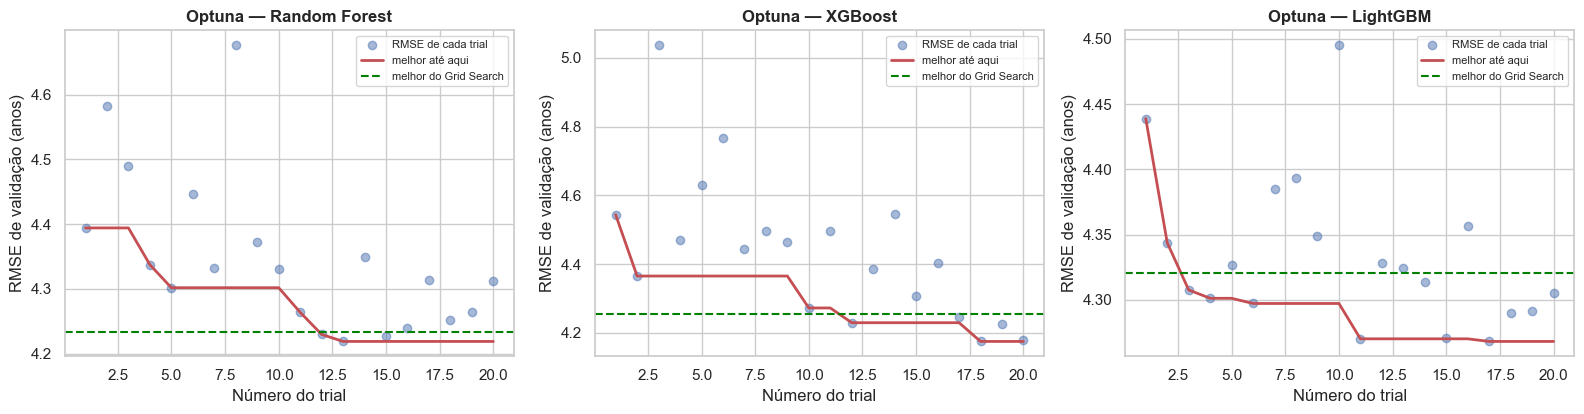

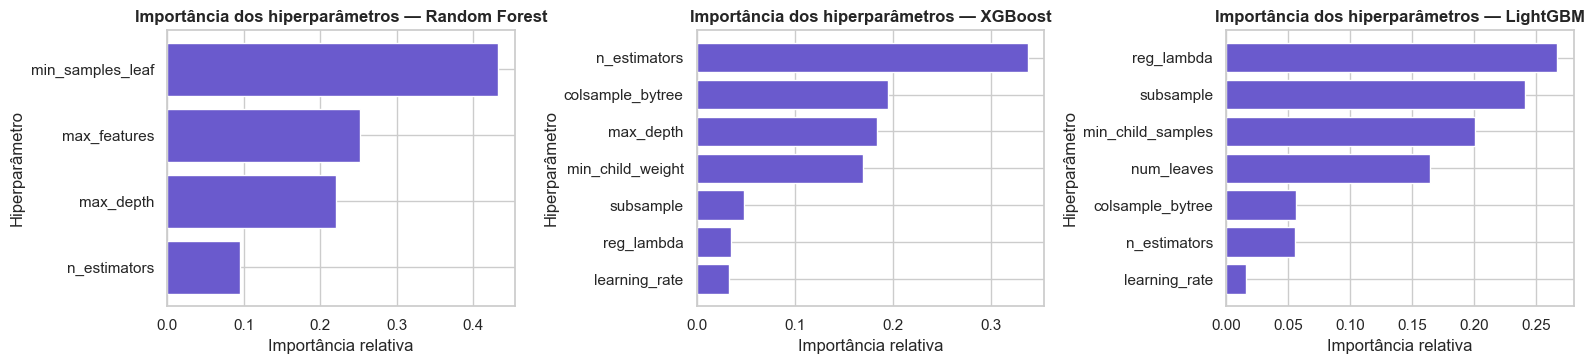

**Interpretação.** Random Forest: melhor trial foi o nº 13 de 20 (RMSE 4.219); XGBoost: melhor trial foi o nº 18 de 20 (RMSE 4.175); LightGBM: melhor trial foi o nº 17 de 20 (RMSE 4.268). Os primeiros 8 trials são exploração aleatória; depois o TPE concentra a busca em regiões promissoras. Se o melhor trial ocorre cedo e a curva 'melhor até aqui' fica plana, a busca estabilizou; se ocorre perto do fim, mais trials poderiam melhorar. Os gráficos de importância indicam a quais hiperparâmetros o erro de validação é mais sensível (onde vale concentrar esforço de tuning).

In [24]:
secao("4.5 (b)", "Gráficos do Optuna: histórico de otimização e importância dos hiperparâmetros", "#c62828")
# Gráficos do Optuna: histórico de otimização e importância dos hiperparâmetros
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))
for ax, nome in zip(axes, MODELOS):
    v = np.array([t.value for t in OPT[nome]["estudo"].trials])
    ax.plot(np.arange(1, len(v) + 1), v, "o", alpha=.5, label="RMSE de cada trial"); ax.plot(np.arange(1, len(v) + 1), np.minimum.accumulate(v), "r-", lw=2, label="melhor até aqui")
    ax.axhline(-GRID[nome]["gs"].best_score_, ls="--", c="green", label="melhor do Grid Search")
    ax.set_title(f"Optuna — {nome}"); ax.set_xlabel("Número do trial"); ax.set_ylabel("RMSE de validação (anos)"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))
for ax, nome in zip(axes, MODELOS):
    try:
        imp = optuna.importance.get_param_importances(OPT[nome]["estudo"])
        ax.barh(list(imp)[::-1], list(imp.values())[::-1], color="slateblue"); ax.set_title(f"Importância dos hiperparâmetros — {nome}"); ax.set_xlabel("Importância relativa"); ax.set_ylabel("Hiperparâmetro")
    except Exception as e:
        ax.text(.05, .5, f"indisponível: {type(e).__name__}"); ax.set_axis_off()
plt.tight_layout(); plt.show()
md("**Interpretação.** " + "; ".join(f"{n}: melhor trial foi o nº {OPT[n]['estudo'].best_trial.number + 1} de {len(OPT[n]['estudo'].trials)} (RMSE {OPT[n]['estudo'].best_value:.3f})" for n in MODELOS) +
   ". Os primeiros 8 trials são exploração aleatória; depois o TPE concentra a busca em regiões promissoras. Se o melhor trial ocorre cedo e a curva 'melhor até aqui' fica plana, a busca estabilizou; "
   "se ocorre perto do fim, mais trials poderiam melhorar. Os gráficos de importância indicam a quais hiperparâmetros o erro de validação é mais sensível (onde vale concentrar esforço de tuning).")

### <span style="color:#c62828">4.5 (c)</span> — Grid Search × Optuna  

<div style="background:#c62828;color:white;padding:8px 14px;border-radius:6px;font-size:16px;margin:6px 0"><b>▶ 4.5 (c)</b> &nbsp;|&nbsp; Comparação: qualidade da solução, custo, estabilidade e comportamento da busca</div>

,RMSE CV Grid,RMSE CV Optuna,Δ (Optuna − Grid),avaliações Grid,avaliações Optuna,tempo Grid (s),tempo Optuna (s),dp RMSE entre combinações Grid,dp RMSE entre trials Optuna
modelo,,,,,,,,,
Random Forest,4.233,4.219,-0.014,24,20,13.4,10.5,0.146,0.122
XGBoost,4.254,4.175,-0.079,24,20,4.4,4.0,0.082,0.212
LightGBM,4.320,4.268,-0.052,24,20,2.6,1.9,0.116,0.058


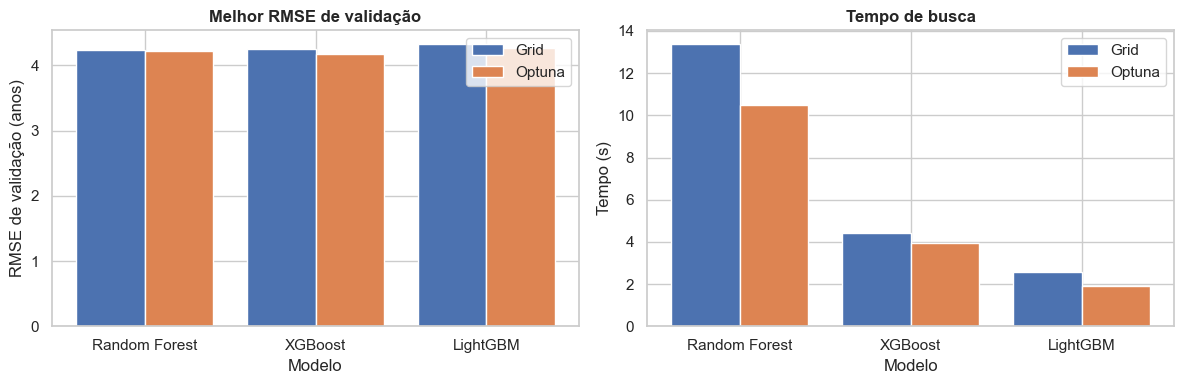

**Leitura.** Random Forest: Optuna melhor que o Grid em 0.014 anos, com 20 avaliações contra 24, mais rápido; XGBoost: Optuna melhor que o Grid em 0.079 anos, com 20 avaliações contra 24, mais rápido; LightGBM: Optuna melhor que o Grid em 0.052 anos, com 20 avaliações contra 24, mais rápido.  
**Qualidade:** diferenças menores que o desvio entre folds não indicam um método superior.  
**Custo:** o Grid cresce multiplicativamente com o nº de hiperparâmetros e valores; o Optuna tem orçamento fixo (trials) e explora espaços contínuos.  
**Estabilidade/comportamento:** o Grid é determinístico e cobre uma malha regular (bom para ver sensibilidade); o Optuna é guiado pelos resultados anteriores e depende da semente, mas pode achar combinações fora da malha.

In [25]:
secao("4.5 (c)", "Comparação: qualidade da solução, custo, estabilidade e comportamento da busca", "#c62828")
# (c) Comparação: qualidade da solução, custo, estabilidade e comportamento da busca
comp = pd.DataFrame([{"modelo": n, "RMSE CV Grid": -GRID[n]["gs"].best_score_, "RMSE CV Optuna": OPT[n]["estudo"].best_value,
                      "Δ (Optuna − Grid)": OPT[n]["estudo"].best_value + GRID[n]["gs"].best_score_,
                      "avaliações Grid": GRID[n]["n_comb"], "avaliações Optuna": len(OPT[n]["estudo"].trials),
                      "tempo Grid (s)": GRID[n]["tempo"], "tempo Optuna (s)": OPT[n]["tempo"],
                      "dp RMSE entre combinações Grid": np.std(-GRID[n]["gs"].cv_results_["mean_test_score"], ddof=1),
                      "dp RMSE entre trials Optuna": np.std([t.value for t in OPT[n]["estudo"].trials], ddof=1)} for n in MODELOS]).set_index("modelo")
mostrar(comp, fmt={c: "{:.3f}" for c in comp.columns} | {"avaliações Grid": "{:.0f}", "avaliações Optuna": "{:.0f}", "tempo Grid (s)": "{:.1f}", "tempo Optuna (s)": "{:.1f}"})
fig, axes = plt.subplots(1, 2, figsize=(12, 4)); x = np.arange(3)
axes[0].bar(x - .2, comp["RMSE CV Grid"], .4, label="Grid"); axes[0].bar(x + .2, comp["RMSE CV Optuna"], .4, label="Optuna")
axes[0].set_xticks(x, comp.index); axes[0].set_title("Melhor RMSE de validação"); axes[0].set_ylabel("RMSE de validação (anos)"); axes[0].legend()
axes[1].bar(x - .2, comp["tempo Grid (s)"], .4, label="Grid"); axes[1].bar(x + .2, comp["tempo Optuna (s)"], .4, label="Optuna")
axes[1].set_xticks(x, comp.index); axes[1].set_title("Tempo de busca"); axes[1].set_ylabel("Tempo (s)"); axes[1].legend()
for a in axes: a.set_xlabel("Modelo")
plt.tight_layout(); plt.show()
md("**Leitura.** " + "; ".join(
   f"{n}: Optuna {'melhor' if d < 0 else 'pior'} que o Grid em {abs(d):.3f} anos, com {comp.loc[n, 'avaliações Optuna']:.0f} avaliações contra {comp.loc[n, 'avaliações Grid']:.0f}, "
   f"{'mais rápido' if comp.loc[n, 'tempo Optuna (s)'] < comp.loc[n, 'tempo Grid (s)'] else 'mais lento'}" for n, d in comp["Δ (Optuna − Grid)"].items()) +
   ".  \n**Qualidade:** diferenças menores que o desvio entre folds não indicam um método superior.  \n"
   "**Custo:** o Grid cresce multiplicativamente com o nº de hiperparâmetros e valores; o Optuna tem orçamento fixo (trials) e explora espaços contínuos.  \n"
   "**Estabilidade/comportamento:** o Grid é determinístico e cobre uma malha regular (bom para ver sensibilidade); o Optuna é guiado pelos resultados anteriores e depende da semente, mas pode achar combinações fora da malha.")

<a id="s4_6"></a>
<div style="background:#00838f;color:white;padding:18px 22px;border-radius:10px;margin:28px 0 8px 0"><div style="font-size:15px;opacity:.85">SEÇÃO 4.6 &nbsp; <a href="#toc" style="color:#fff;text-decoration:underline">↑ voltar ao índice</a></div><div style="font-size:28px;font-weight:bold;margin:4px 0 8px 0">4.6 — Escolha do melhor modelo e análise de overfitting/underfitting</div><ul style="margin:0;padding-left:20px;font-size:14px"><li><b>(a)</b> Tabela das 9 configurações e escolha </li><li><b>(b)</b> Treino × validação e curva de aprendizado </li><li><b>(c)</b> Importância das variáveis e gráficos de desempenho </li></ul></div>

Decisão baseada **apenas em treino e validação cruzada**. Diagnóstico por (i) RMSE de treino × validação e gap $\Delta_\downarrow$, (ii) desvio entre folds, (iii) comparação com a referência (média) e (iv) **curva de aprendizado**.

### <span style="color:#00838f">4.6 (a)</span> — Tabela das nove configurações e escolha  

In [26]:
secao("4.6 (a)", "Tabela única com as 9 configurações (baseline, Grid Search e Optuna de cada modelo)", "#00838f")
# (a) Tabela única com as 9 configurações (baseline, Grid Search e Optuna de cada modelo)
ordem_est = {"Baseline": 0, "Grid Search": 1, "Optuna": 2}
tab9 = pd.DataFrame(RESULTADOS)
tab9["_o"] = tab9["modelo"].map({m: i for i, m in enumerate(MODELOS)}) * 10 + tab9["estratégia"].map(ordem_est)
tab9 = tab9.sort_values("_o").reset_index(drop=True); tab9.insert(0, "configuração", tab9["modelo"] + " — " + tab9["estratégia"])
assert len(tab9) == 9
COLS9 = ["configuração", "RMSE treino", "RMSE CV (média)", "RMSE CV (dp)", "gap (CV−treino)", "gap relativo", "MAE CV", "R² CV", "tempo fit/fold (s)", "tempo busca (s)", "nº ajustes"]
tabela9 = tab9[COLS9].set_index("configuração")
mostrar(tabela9, fmt={c: "{:.3f}" for c in tabela9.columns} | {"nº ajustes": "{:.0f}", "tempo busca (s)": "{:.1f}"}, gradiente=["RMSE CV (média)"])
md("**Hiperparâmetros de cada configuração**")
mostrar(tab9[["configuração", "hiperparâmetros"]].set_index("configuração"))
md("*Baseline: tempo de busca = 0 s (não houve busca) e 5 ajustes (um por fold). Grid e Optuna: ajustes = avaliações × 5 folds.*")

<div style="background:#00838f;color:white;padding:8px 14px;border-radius:6px;font-size:16px;margin:6px 0"><b>▶ 4.6 (a)</b> &nbsp;|&nbsp; Tabela única com as 9 configurações (baseline, Grid Search e Optuna de cada modelo)</div>

,RMSE treino,RMSE CV (média),RMSE CV (dp),gap (CV−treino),gap relativo,MAE CV,R² CV,tempo fit/fold (s),tempo busca (s),nº ajustes
configuração,,,,,,,,,,
Random Forest — Baseline,0.793,4.536,0.535,3.743,0.825,3.179,0.755,0.859,0.0,5
Random Forest — Grid Search,1.344,4.233,0.388,2.889,0.683,3.076,0.792,0.275,13.4,120
Random Forest — Optuna,1.137,4.219,0.401,3.081,0.730,3.076,0.794,0.292,10.5,100
XGBoost — Baseline,0.730,4.236,0.308,3.506,0.828,3.102,0.789,0.154,0.0,5
XGBoost — Grid Search,1.300,4.254,0.332,2.954,0.694,3.120,0.788,0.175,4.4,120
XGBoost — Optuna,0.478,4.175,0.292,3.697,0.885,3.070,0.795,0.218,4.0,100
LightGBM — Baseline,0.858,4.402,0.505,3.544,0.805,3.138,0.770,0.076,0.0,5
LightGBM — Grid Search,1.647,4.320,0.457,2.673,0.619,3.122,0.782,0.053,2.6,120
LightGBM — Optuna,1.440,4.268,0.454,2.828,0.663,3.100,0.788,0.071,1.9,100


**Hiperparâmetros de cada configuração**

,hiperparâmetros
configuração,
Random Forest — Baseline,"n_estimators=150, max_depth=None, min_samples_leaf=1, max_features=1.0, random_state=42"
Random Forest — Grid Search,"n_estimators=100, max_depth=None, min_samples_leaf=3, max_features=0.5, random_state=42"
Random Forest — Optuna,"n_estimators=100, max_depth=16, min_samples_leaf=2, max_features=0.4119, random_state=42"
XGBoost — Baseline,"n_estimators=150, learning_rate=0.1, max_depth=6, min_child_weight=1, subsample=1.0, colsample_bytree=1.0, reg_lambda=1.0, random_state=42"
XGBoost — Grid Search,"n_estimators=200, learning_rate=0.05, max_depth=5, min_child_weight=1, subsample=0.8, colsample_bytree=1.0, reg_lambda=1.0, random_state=42"
XGBoost — Optuna,"n_estimators=250, learning_rate=0.1163, max_depth=6, min_child_weight=5, subsample=0.6514, colsample_bytree=0.8726, reg_lambda=0.2977, r..."
LightGBM — Baseline,"n_estimators=150, learning_rate=0.1, num_leaves=31, min_child_samples=20, subsample=1.0, colsample_bytree=1.0, reg_lambda=0.0, random_st..."
LightGBM — Grid Search,"n_estimators=200, learning_rate=0.05, num_leaves=15, min_child_samples=30, subsample=1.0, colsample_bytree=1.0, reg_lambda=0.0, random_s..."
LightGBM — Optuna,"n_estimators=200, learning_rate=0.0487, num_leaves=22, min_child_samples=17, subsample=0.8565, colsample_bytree=0.6706, reg_lambda=6.246..."


*Baseline: tempo de busca = 0 s (não houve busca) e 5 ajustes (um por fold). Grid e Optuna: ajustes = avaliações × 5 folds.*

In [27]:
secao("4.6 (a)", "Seleciona a configuração promovida pela regra fixada na Seção 4.3 (apenas treino/validação)", "#00838f")
# Seleciona a configuração promovida pela regra fixada na Seção 4.3 (apenas treino/validação)
def selecionar(tab, k=K_FOLDS):
    melhor = tab.loc[tab["RMSE CV (média)"].idxmin()]
    limite = melhor["RMSE CV (média)"] + melhor["RMSE CV (dp)"] / np.sqrt(k)
    elegiveis = tab[tab["RMSE CV (média)"] <= limite].copy()
    escolhida = elegiveis.sort_values(["gap (CV−treino)", "tempo fit/fold (s)"]).iloc[0]
    return melhor, limite, elegiveis, escolhida

melhor_cv, limite_1se, elegiveis, escolhida = selecionar(tab9)
MODELO_ESCOLHIDO, ESTRATEGIA_ESCOLHIDA = escolhida["modelo"], escolhida["estratégia"]
PARAMS_ESCOLHIDOS = dict(escolhida["params"]); CONFIG_ESCOLHIDA = escolhida["configuração"]

md(f"- Melhor RMSE de CV: **{melhor_cv['configuração']}** ({melhor_cv['RMSE CV (média)']:.3f} ± {melhor_cv['RMSE CV (dp)']:.3f})  \n"
   f"- Limite de 1 erro-padrão: **{limite_1se:.3f}** → configurações empatadas: {', '.join(elegiveis['configuração'])}  \n"
   f"- **Promovida ao teste (menor gap entre as elegíveis; depois, menor tempo): {CONFIG_ESCOLHIDA}**")
cand = elegiveis.set_index("configuração")[["RMSE CV (média)", "RMSE CV (dp)", "gap (CV−treino)", "gap relativo", "tempo fit/fold (s)", "tempo busca (s)"]]
mostrar(cand, fmt={c: "{:.3f}" for c in cand.columns})
outros = [c for c in elegiveis["configuração"] if c != CONFIG_ESCOLHIDA]
empate_txt = ("as configurações " + ", ".join(outros) + " também estão dentro de 1 erro-padrão; a escolha entre elas é de parcimônia/estabilidade, não de superioridade comprovada.") if outros else "nenhuma outra configuração está dentro de 1 erro-padrão."
md(f"**Justificativa (calculada de treino/validação):**  \n"
   f"- *Desempenho:* RMSE de CV {escolhida['RMSE CV (média)']:.3f} anos vs. {melhor_cv['RMSE CV (média)']:.3f} da melhor absoluta; diferença {escolhida['RMSE CV (média)'] - melhor_cv['RMSE CV (média)']:+.3f}, "
   f"{'dentro' if escolhida['RMSE CV (média)'] <= limite_1se else 'fora'} de 1 erro-padrão ({melhor_cv['RMSE CV (dp)'] / np.sqrt(K_FOLDS):.3f}).  \n"
   f"- *Estabilidade:* dp entre folds {escolhida['RMSE CV (dp)']:.3f} ({escolhida['RMSE CV (dp)'] / escolhida['RMSE CV (média)'] * 100:.1f}% da média).  \n"
   f"- *Overfitting:* gap CV−treino {escolhida['gap (CV−treino)']:.3f} ({escolhida['gap relativo'] * 100:.0f}% do erro de CV); o menor entre as empatadas.  \n"
   f"- *Custo:* {escolhida['tempo fit/fold (s)']:.2f}s por ajuste; busca {escolhida['tempo busca (s)']:.0f}s.  \n"
   f"- *Empate técnico:* {empate_txt}  \n- O resultado do teste **não** foi consultado para esta decisão.")

<div style="background:#00838f;color:white;padding:8px 14px;border-radius:6px;font-size:16px;margin:6px 0"><b>▶ 4.6 (a)</b> &nbsp;|&nbsp; Seleciona a configuração promovida pela regra fixada na Seção 4.3 (apenas treino/validação)</div>

- Melhor RMSE de CV: **XGBoost — Optuna** (4.175 ± 0.292)  
- Limite de 1 erro-padrão: **4.305** → configurações empatadas: Random Forest — Grid Search, Random Forest — Optuna, XGBoost — Baseline, XGBoost — Grid Search, XGBoost — Optuna, LightGBM — Optuna  
- **Promovida ao teste (menor gap entre as elegíveis; depois, menor tempo): LightGBM — Optuna**

,RMSE CV (média),RMSE CV (dp),gap (CV−treino),gap relativo,tempo fit/fold (s),tempo busca (s)
configuração,,,,,,
Random Forest — Grid Search,4.233,0.388,2.889,0.683,0.275,13.362
Random Forest — Optuna,4.219,0.401,3.081,0.730,0.292,10.483
XGBoost — Baseline,4.236,0.308,3.506,0.828,0.154,0.000
XGBoost — Grid Search,4.254,0.332,2.954,0.694,0.175,4.428
XGBoost — Optuna,4.175,0.292,3.697,0.885,0.218,3.953
LightGBM — Optuna,4.268,0.454,2.828,0.663,0.071,1.917


**Justificativa (calculada de treino/validação):**  
- *Desempenho:* RMSE de CV 4.268 anos vs. 4.175 da melhor absoluta; diferença +0.093, dentro de 1 erro-padrão (0.130).  
- *Estabilidade:* dp entre folds 0.454 (10.6% da média).  
- *Overfitting:* gap CV−treino 2.828 (66% do erro de CV); o menor entre as empatadas.  
- *Custo:* 0.07s por ajuste; busca 2s.  
- *Empate técnico:* as configurações Random Forest — Grid Search, Random Forest — Optuna, XGBoost — Baseline, XGBoost — Grid Search, XGBoost — Optuna também estão dentro de 1 erro-padrão; a escolha entre elas é de parcimônia/estabilidade, não de superioridade comprovada.  
- O resultado do teste **não** foi consultado para esta decisão.

<div style="background:#00838f;color:white;padding:8px 14px;border-radius:6px;font-size:16px;margin:6px 0"><b>▶ 4.6 (a)</b> &nbsp;|&nbsp; Comparação gráfica das 9 configurações: erro de validação, treino × validação e tempo de ajuste</div>

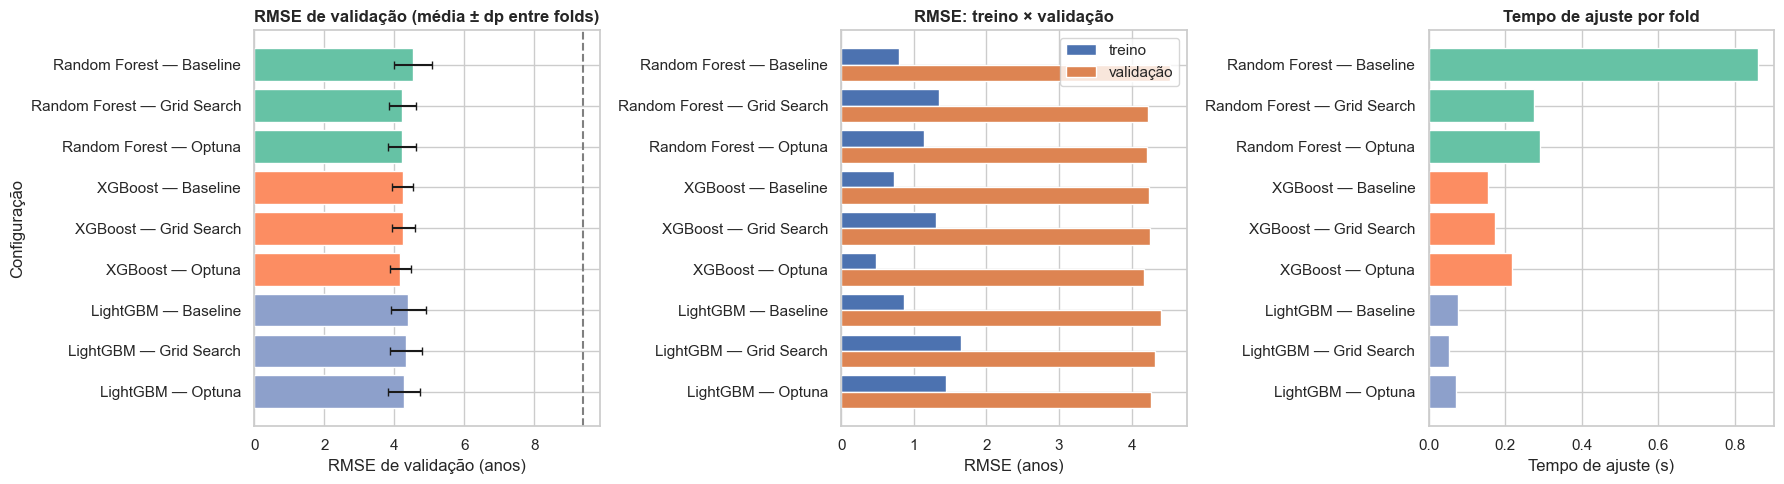

Os três gráficos resumem a tabela: erro de validação com dispersão entre folds (linha tracejada = referência da média), distância treino × validação (overfitting) e custo de ajuste. Configurações cujas médias diferem menos que o desvio entre folds não são distinguíveis nesta base.

In [28]:
secao("4.6 (a)", "Comparação gráfica das 9 configurações: erro de validação, treino × validação e tempo de ajuste", "#00838f")
# Comparação gráfica das 9 configurações: erro de validação, treino × validação e tempo de ajuste
fig, axes = plt.subplots(1, 3, figsize=(18, 5)); y_ = np.arange(9)[::-1]; nomes = tab9["configuração"]
cores = [sns.color_palette("Set2", 3)[MODELOS.index(m)] for m in tab9["modelo"]]
axes[0].barh(y_, tab9["RMSE CV (média)"], xerr=tab9["RMSE CV (dp)"], color=cores, capsize=3); axes[0].axvline(ref["RMSE CV (média)"], ls="--", c="gray")
axes[0].set_yticks(y_, nomes); axes[0].set_title("RMSE de validação (média ± dp entre folds)"); axes[0].set_xlabel("RMSE de validação (anos)")
axes[1].barh(y_ + .2, tab9["RMSE treino"], .4, label="treino"); axes[1].barh(y_ - .2, tab9["RMSE CV (média)"], .4, label="validação")
axes[1].set_yticks(y_, nomes); axes[1].set_title("RMSE: treino × validação"); axes[1].legend(); axes[1].set_xlabel("RMSE (anos)")
axes[2].barh(y_, tab9["tempo fit/fold (s)"], color=cores); axes[2].set_yticks(y_, nomes); axes[2].set_title("Tempo de ajuste por fold"); axes[2].set_xlabel("Tempo de ajuste (s)")
axes[0].set_ylabel("Configuração")
plt.tight_layout(); plt.show()
md("Os três gráficos resumem a tabela: erro de validação com dispersão entre folds (linha tracejada = referência da média), distância treino × validação (overfitting) e custo de ajuste. "
   "Configurações cujas médias diferem menos que o desvio entre folds não são distinguíveis nesta base.")

### <span style="color:#00838f">4.6 (b)</span> — Treino × validação e curva de aprendizado 

<div style="background:#00838f;color:white;padding:8px 14px;border-radius:6px;font-size:16px;margin:6px 0"><b>▶ 4.6 (b)</b> &nbsp;|&nbsp; Diagnóstico de overfitting/underfitting por configuração</div>

,RMSE treino,RMSE CV (média),RMSE CV (dp),gap (CV−treino),gap relativo,R² treino,R² CV,dp/média (CV),diagnóstico
configuração,,,,,,,,,
Random Forest — Baseline,0.793,4.536,0.535,3.743,0.825,0.993,0.755,0.118,gap relativo ≥ 50% → possível overfitting
Random Forest — Grid Search,1.344,4.233,0.388,2.889,0.683,0.980,0.792,0.092,gap relativo ≥ 50% → possível overfitting
Random Forest — Optuna,1.137,4.219,0.401,3.081,0.730,0.985,0.794,0.095,gap relativo ≥ 50% → possível overfitting
XGBoost — Baseline,0.730,4.236,0.308,3.506,0.828,0.994,0.789,0.073,gap relativo ≥ 50% → possível overfitting
XGBoost — Grid Search,1.300,4.254,0.332,2.954,0.694,0.981,0.788,0.078,gap relativo ≥ 50% → possível overfitting
XGBoost — Optuna,0.478,4.175,0.292,3.697,0.885,0.997,0.795,0.070,gap relativo ≥ 50% → possível overfitting
LightGBM — Baseline,0.858,4.402,0.505,3.544,0.805,0.992,0.770,0.115,gap relativo ≥ 50% → possível overfitting
LightGBM — Grid Search,1.647,4.320,0.457,2.673,0.619,0.969,0.782,0.106,gap relativo ≥ 50% → possível overfitting
LightGBM — Optuna,1.440,4.268,0.454,2.828,0.663,0.977,0.788,0.106,gap relativo ≥ 50% → possível overfitting


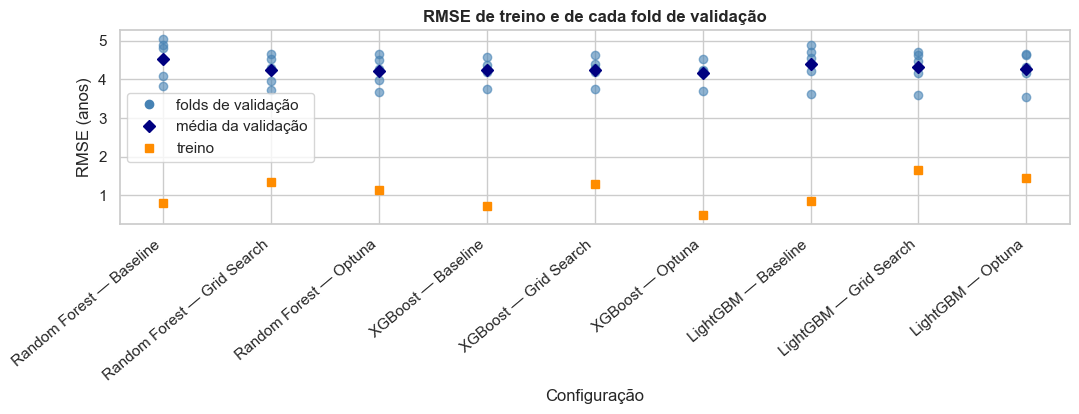

In [29]:
secao("4.6 (b)", "Diagnóstico de overfitting/underfitting por configuração", "#00838f")
# (b) Diagnóstico de overfitting/underfitting por configuração
diag9 = tab9[["configuração", "RMSE treino", "RMSE CV (média)", "RMSE CV (dp)", "gap (CV−treino)", "gap relativo", "R² treino", "R² CV"]].copy()
diag9["dp/média (CV)"] = diag9["RMSE CV (dp)"] / diag9["RMSE CV (média)"]
diag9["diagnóstico"] = [diagnostico(r) for r in tab9.to_dict("records")]
mostrar(diag9.set_index("configuração"), fmt={c: "{:.3f}" for c in diag9.columns if c not in ("configuração", "diagnóstico")})

fig, ax = plt.subplots(figsize=(11, 4.3))
for i, r in tab9.iterrows():
    ax.plot([i] * len(r["_cv_folds"]), r["_cv_folds"], "o", c="steelblue", alpha=.6); ax.plot(i, r["RMSE CV (média)"], "D", c="navy"); ax.plot(i, r["RMSE treino"], "s", c="darkorange")
from matplotlib.lines import Line2D
ax.set_xticks(range(9), tab9["configuração"], rotation=40, ha="right")
ax.legend(handles=[Line2D([], [], marker="o", ls="", c="steelblue", label="folds de validação"), Line2D([], [], marker="D", ls="", c="navy", label="média da validação"),
                   Line2D([], [], marker="s", ls="", c="darkorange", label="treino")])
ax.set_xlabel("Configuração"); ax.set_ylabel("RMSE (anos)"); ax.set_title("RMSE de treino e de cada fold de validação")
plt.tight_layout(); plt.show()

<div style="background:#00838f;color:white;padding:8px 14px;border-radius:6px;font-size:16px;margin:6px 0"><b>▶ 4.6 (b)</b> &nbsp;|&nbsp; Curva de aprendizado da configuração escolhida (mesmos folds)</div>

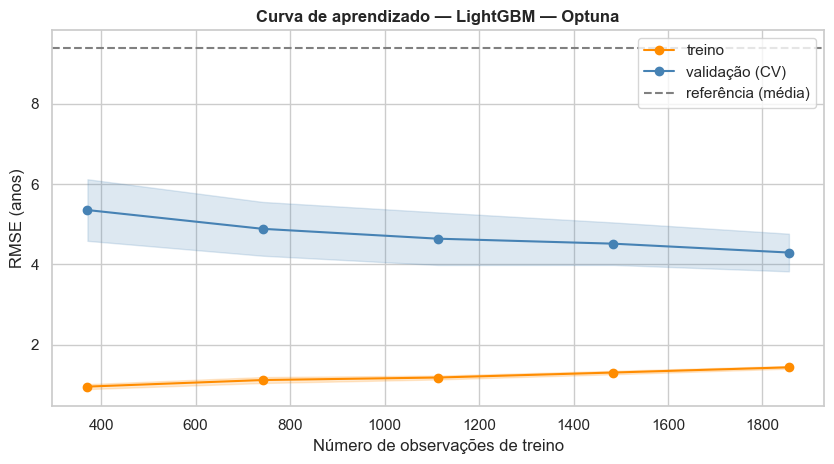

**Interpretação.** Com 371 observações o RMSE de validação é 5.353; com 1856, 4.296. Na última ampliação do treino o erro de validação variou **+0.221** anos (positivo = ainda melhorando). Gap final treino × validação: **2.855** anos. O erro de validação ainda cai com mais dados, então **mais observações ajudariam**. O gap grande e persistente é compatível com **variância elevada / overfitting moderado**, típico de árvores, sem que isso invalide a generalização por si só. Como o erro de validação fica bem abaixo da referência da média, **não há evidência de underfitting**.

⏱ curva de aprendizado em 0.6s


In [30]:
secao("4.6 (b)", "Curva de aprendizado da configuração escolhida (mesmos folds)", "#00838f")
# Curva de aprendizado da configuração escolhida (mesmos folds)
t0 = time.perf_counter()
n_abs, lc_tr, lc_va = learning_curve(montar_pipeline(construir(MODELO_ESCOLHIDO, PARAMS_ESCOLHIDOS)), X_treino, y_treino, cv=FOLDS,
                                     train_sizes=np.linspace(0.2, 1.0, 5), scoring=PRINCIPAL, n_jobs=N_JOBS, shuffle=False)
lc_tr, lc_va = -lc_tr, -lc_va
fig, ax = plt.subplots(figsize=(8.5, 4.8))
for m, c, lab in [(lc_tr, "darkorange", "treino"), (lc_va, "steelblue", "validação (CV)")]:
    ax.plot(n_abs, m.mean(1), "o-", c=c, label=lab); ax.fill_between(n_abs, m.mean(1) - m.std(1, ddof=1), m.mean(1) + m.std(1, ddof=1), color=c, alpha=.18)
ax.axhline(ref["RMSE CV (média)"], ls="--", c="gray", label="referência (média)")
ax.set_xlabel("Número de observações de treino"); ax.set_ylabel("RMSE (anos)"); ax.set_title(f"Curva de aprendizado — {CONFIG_ESCOLHIDA}"); ax.legend()
plt.tight_layout(); plt.show()
queda_final = lc_va.mean(1)[-2] - lc_va.mean(1)[-1]; gap_final = lc_va.mean(1)[-1] - lc_tr.mean(1)[-1]
md(f"**Interpretação.** Com {int(n_abs[0])} observações o RMSE de validação é {lc_va.mean(1)[0]:.3f}; com {int(n_abs[-1])}, {lc_va.mean(1)[-1]:.3f}. "
   f"Na última ampliação do treino o erro de validação variou **{queda_final:+.3f}** anos (positivo = ainda melhorando). Gap final treino × validação: **{gap_final:.3f}** anos. "
   + ("O erro de validação ainda cai com mais dados, então **mais observações ajudariam**. " if queda_final > 0.05 else "O erro de validação praticamente estabilizou, então **mais dados trariam pouco ganho**. ")
   + ("O gap grande e persistente é compatível com **variância elevada / overfitting moderado**, típico de árvores, sem que isso invalide a generalização por si só. " if gap_final / lc_va.mean(1)[-1] > 0.25
      else "O gap é pequeno em relação ao erro: **boa generalização**, sem sinal forte de overfitting. ")
   + "Como o erro de validação fica bem abaixo da referência da média, **não há evidência de underfitting**.")
print(f"⏱ curva de aprendizado em {time.perf_counter() - t0:.1f}s")

### <span style="color:#00838f">4.6 (c)</span> — Importância das variáveis e desempenho do modelo escolhido  

Duas visões, **ambas sem o teste**: (a) importância *nativa* do modelo ajustado em $\mathcal{D}_{treino}$ (ganho/impureza — pode favorecer variáveis contínuas); (b) importância por **permutação** nos folds de validação (queda do desempenho em países não vistos ao embaralhar cada variável original), mais fiel ao que importa para generalização. Para o desempenho, usamos as **previsões fora-da-amostra da CV** (cada país é previsto por um modelo que não o viu). Importância ≠ causalidade.

<div style="background:#00838f;color:white;padding:8px 14px;border-radius:6px;font-size:16px;margin:6px 0"><b>▶ 4.6 (c)</b> &nbsp;|&nbsp; Importância das variáveis: nativa (treino) e por permutação (folds de validação)</div>

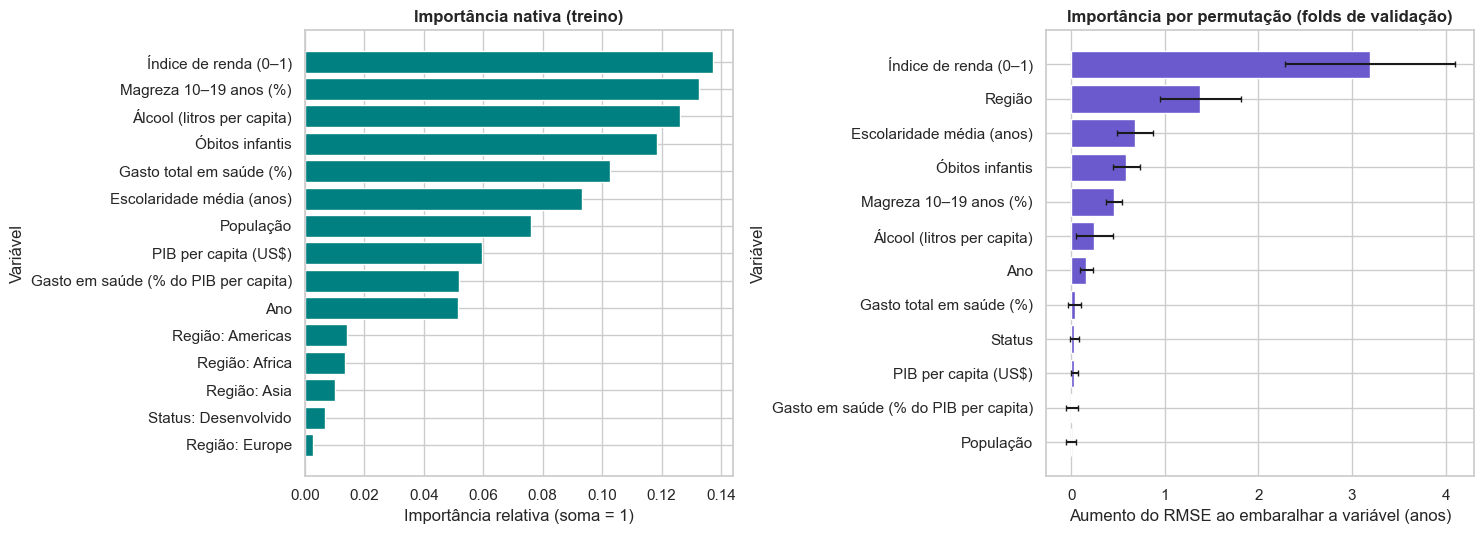

**Interpretação.** Por permutação, as variáveis cuja perda mais degrada o RMSE de validação são: `indice_renda` (+3.19 anos), `regiao` (+1.38 anos), `escolaridade_anos` (+0.68 anos), `obitos_infantis` (+0.59 anos). Pela importância nativa, as mais usadas nas divisões: `indice_renda` (14%), `magreza_1_19` (13%), `alcool` (13%), `obitos_infantis` (12%). Se as duas visões concordam no topo, a leitura é robusta; divergências costumam vir de variáveis correlacionadas (ex.: `indice_renda`/`escolaridade_anos`), entre as quais a importância se **divide**. Variáveis com importância próxima de zero (ou negativa) pouco contribuem para prever países novos. Isto descreve o **modelo**, não relações causais.

⏱ importâncias em 1.2s


In [42]:
secao("4.6 (c)", "Importância das variáveis: nativa (treino) e por permutação (folds de validação)", "#00838f")
# Importância das variáveis: nativa (treino) e por permutação (folds de validação)
t0 = time.perf_counter()
modelo_importancia = montar_pipeline(construir(MODELO_ESCOLHIDO, PARAMS_ESCOLHIDOS)).fit(X_treino, y_treino)
nomes_feat = modelo_importancia.named_steps["prep"].get_feature_names_out()
nativa = pd.Series(modelo_importancia.named_steps["model"].feature_importances_, index=nomes_feat).sort_values(ascending=False); nativa = nativa / nativa.sum()

perm = []
for a, b in FOLDS:
    p = clone(montar_pipeline(construir(MODELO_ESCOLHIDO, PARAMS_ESCOLHIDOS))).fit(X_treino.iloc[a], y_treino.iloc[a])
    perm.append(permutation_importance(p, X_treino.iloc[b], y_treino.iloc[b], scoring=PRINCIPAL, n_repeats=3, random_state=SEED, n_jobs=N_JOBS).importances_mean)
perm = pd.DataFrame(perm, columns=FEATURES); perm_m = perm.mean().sort_values(ascending=False); perm_sd = perm.std(ddof=1)[perm_m.index]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
top = nativa.head(15)[::-1]; axes[0].barh([rot(i) for i in top.index], top.values, color="teal")
axes[0].set_xlabel("Importância relativa (soma = 1)"); axes[0].set_ylabel("Variável"); axes[0].set_title("Importância nativa (treino)")
axes[1].barh([rot(i) for i in perm_m.index[::-1]], perm_m.values[::-1], xerr=perm_sd.values[::-1], color="slateblue", capsize=2)
axes[1].set_xlabel("Aumento do RMSE ao embaralhar a variável (anos)"); axes[1].set_ylabel("Variável"); axes[1].set_title("Importância por permutação (folds de validação)")
plt.tight_layout(); plt.show()
md("**Interpretação.** Por permutação, as variáveis cuja perda mais degrada o RMSE de validação são: " + ", ".join(f"`{k}` (+{v:.2f} anos)" for k, v in perm_m.head(4).items()) +
   ". Pela importância nativa, as mais usadas nas divisões: " + ", ".join(f"`{k}` ({v * 100:.0f}%)" for k, v in nativa.head(4).items()) +
   ". Se as duas visões concordam no topo, a leitura é robusta; divergências costumam vir de variáveis correlacionadas (ex.: `indice_renda`/`escolaridade_anos`), entre as quais a importância se **divide**. "
   "Variáveis com importância próxima de zero (ou negativa) pouco contribuem para prever países novos. Isto descreve o **modelo**, não relações causais.")
print(f"⏱ importâncias em {time.perf_counter() - t0:.1f}s")

<div style="background:#00838f;color:white;padding:8px 14px;border-radius:6px;font-size:16px;margin:6px 0"><b>▶ 4.6 (c)</b> &nbsp;|&nbsp; Desempenho do modelo escolhido (somente treino): observado × previsto e resíduos, com previsões</div>

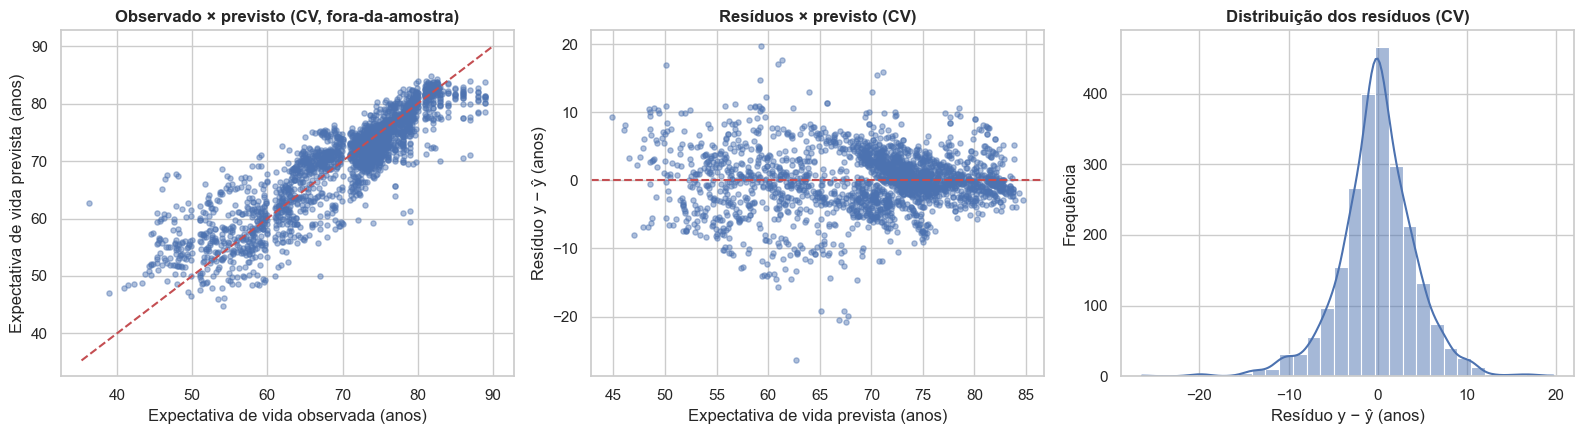

**Interpretação.** Nas previsões fora-da-amostra do treino: RMSE 4.283, MAE 3.097, R² 0.794. Viés médio (y − ŷ) = -0.069 anos; 90% dos erros absolutos ≤ 6.91 anos. Pontos próximos da diagonal indicam boa calibração; curvatura ou funil nos resíduos indicariam viés sistemático ou heterocedasticidade. Esta leitura usa apenas o treino; a avaliação final está na Seção 4.7.

In [43]:
secao("4.6 (c)", "Desempenho do modelo escolhido (somente treino): observado × previsto e resíduos, com previsões", "#00838f")
# Desempenho do modelo escolhido (somente treino): observado × previsto e resíduos, com previsões fora-da-amostra da CV
oof = cross_val_predict(montar_pipeline(construir(MODELO_ESCOLHIDO, PARAMS_ESCOLHIDOS)), X_treino, y_treino, cv=FOLDS, n_jobs=N_JOBS)
res_oof = y_treino.values - oof; m_oof = metricas(y_treino, oof)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].scatter(y_treino, oof, alpha=.45, s=14); lim = [min(y_treino.min(), oof.min()) - 1, max(y_treino.max(), oof.max()) + 1]; axes[0].plot(lim, lim, "r--")
axes[0].set_xlabel("Expectativa de vida observada (anos)"); axes[0].set_ylabel("Expectativa de vida prevista (anos)"); axes[0].set_title("Observado × previsto (CV, fora-da-amostra)")
axes[1].scatter(oof, res_oof, alpha=.45, s=14); axes[1].axhline(0, c="r", ls="--")
axes[1].set_xlabel("Expectativa de vida prevista (anos)"); axes[1].set_ylabel("Resíduo y − ŷ (anos)"); axes[1].set_title("Resíduos × previsto (CV)")
sns.histplot(res_oof, kde=True, bins=30, ax=axes[2]); axes[2].set_xlabel("Resíduo y − ŷ (anos)"); axes[2].set_ylabel("Frequência"); axes[2].set_title("Distribuição dos resíduos (CV)")
plt.tight_layout(); plt.show()
md(f"**Interpretação.** Nas previsões fora-da-amostra do treino: RMSE {m_oof['RMSE']:.3f}, MAE {m_oof['MAE']:.3f}, R² {m_oof['R2']:.3f}. Viés médio (y − ŷ) = {res_oof.mean():+.3f} anos; "
   f"90% dos erros absolutos ≤ {np.quantile(np.abs(res_oof), .9):.2f} anos. Pontos próximos da diagonal indicam boa calibração; curvatura ou funil nos resíduos indicariam viés sistemático ou heterocedasticidade. "
   "Esta leitura usa apenas o treino; a avaliação final está na Seção 4.7.")

<div style="background:#00838f;color:white;padding:8px 14px;border-radius:6px;font-size:16px;margin:6px 0"><b>▶ 4.6 (c)</b> &nbsp;|&nbsp; Complemento — dependência parcial das 3 variáveis numéricas mais importantes (modelo ajustado e</div>

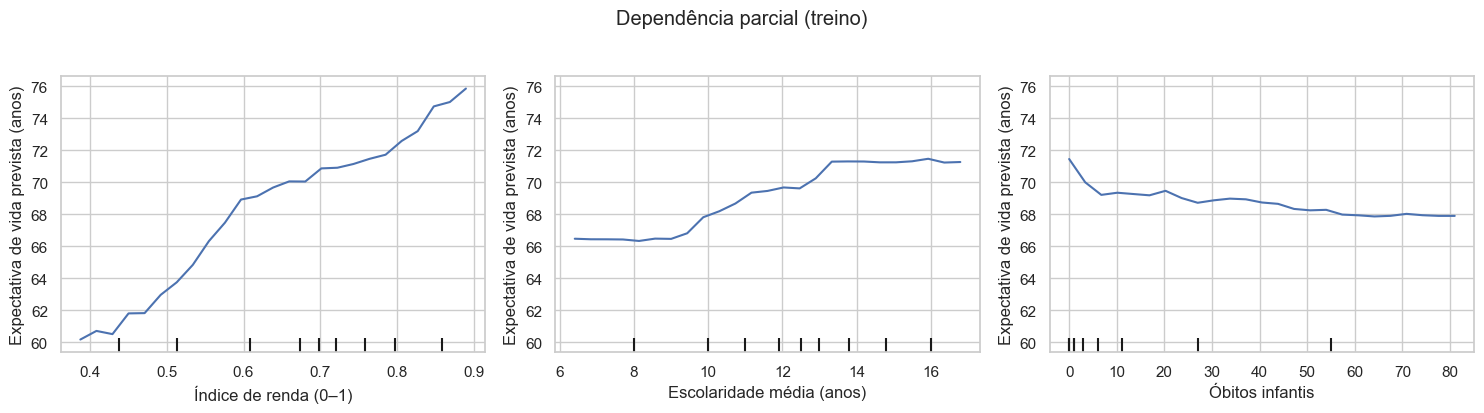

Curvas monótonas indicam associação consistente; trechos planos indicam saturação. A dependência parcial pode enganar quando as variáveis são correlacionadas (assume variação isolada).

In [44]:
secao("4.6 (c)", "Complemento — dependência parcial das 3 variáveis numéricas mais importantes (modelo ajustado e", "#00838f")

# Complemento — dependência parcial das 3 variáveis numéricas mais importantes
# (modelo ajustado em D_treino)
from sklearn.inspection import PartialDependenceDisplay

try:
    top3 = [c for c in perm_m.index if c in VARS_NUM][:3]

    X_pdp = X_treino.copy()
    X_pdp[VARS_NUM] = X_pdp[VARS_NUM].astype("float64")

    for c in VARS_NUM:
        X_pdp[c] = X_pdp[c].fillna(X_pdp[c].median())

    fig, ax = plt.subplots(1, 3, figsize=(15, 4))

    PartialDependenceDisplay.from_estimator(
        modelo_importancia,
        X_pdp,
        top3,
        ax=ax,
        grid_resolution=25,
        method="brute"
    )

    for a_, c_ in zip(ax, top3):
        a_.set_xlabel(rot(c_))
        a_.set_ylabel("Expectativa de vida prevista (anos)")

    plt.suptitle("Dependência parcial (treino)", y=1.03)
    plt.tight_layout()
    plt.show()

    md("Curvas monótonas indicam associação consistente; trechos planos indicam saturação. A dependência parcial pode enganar quando as variáveis são correlacionadas (assume variação isolada).")

except Exception as e:
    print("Dependência parcial não gerada:", type(e).__name__, e)

<a id="s4_7"></a>
<div style="background:#4e342e;color:white;padding:18px 22px;border-radius:10px;margin:28px 0 8px 0"><div style="font-size:15px;opacity:.85">SEÇÃO 4.7 &nbsp;·&nbsp; <a href="#toc" style="color:#fff;text-decoration:underline">↑ voltar ao índice</a></div><div style="font-size:28px;font-weight:bold;margin:4px 0 8px 0">4.7 — Teste final, consistência, GitHub e Streamlit</div><ul style="margin:0;padding-left:20px;font-size:14px"><li><b>(a)</b> Avaliação final no teste (uma única vez) </li><li><b>(b)</b> Teste de consistência (≥ 5 observações) </li><li><b>(c)</b> GitHub, Streamlit e teste de paridade </li></ul></div>

### <span style="color:#4e342e">4.7 (a)</span> — Avaliação final no conjunto de teste 

**Somente agora** $\mathcal{D}_{teste}$ é utilizado. A configuração escolhida é **re-treinada com todo $\mathcal{D}_{treino}$** e avaliada **uma única vez**; o resultado **não** reabre a escolha do modelo.

In [39]:
secao("4.7 (a)", "Modelo final: retreina a configuração escolhida com todo o treino e avalia o teste UMA vez", "#4e342e")
# Modelo final: retreina a configuração escolhida com todo o treino e avalia o teste UMA vez
modelo_final = montar_pipeline(construir(MODELO_ESCOLHIDO, PARAMS_ESCOLHIDOS))
t0 = time.perf_counter(); modelo_final.fit(X_treino, y_treino); tempo_final = time.perf_counter() - t0

_AVALIACOES_TESTE = 0
def avaliar_teste_uma_vez():
    global _AVALIACOES_TESTE
    _AVALIACOES_TESTE += 1
    assert _AVALIACOES_TESTE == 1, "O conjunto de teste só pode ser avaliado uma vez!"
    p = modelo_final.predict(X_teste)
    return p, metricas(y_teste, p)
pred_teste, m_teste = avaliar_teste_uma_vez()
m_treino_full = metricas(y_treino, modelo_final.predict(X_treino))
esc = escolhida
comp_final = pd.DataFrame({"Treino (refit completo)": m_treino_full,
                           "CV (média)": {"RMSE": esc["RMSE CV (média)"], "MAE": esc["MAE CV"], "R2": esc["R² CV"]}, "TESTE": m_teste})
mostrar(comp_final)
z = (m_teste["RMSE"] - esc["RMSE CV (média)"]) / esc["RMSE CV (dp)"]
rmse_ref_teste = float(np.sqrt(mean_squared_error(y_teste, np.full(len(y_teste), y_treino.mean()))))
compat = ("O desempenho no teste é **compatível** com a validação cruzada (dentro de ~2 desvios entre folds), o que apoia a leitura de generalização feita no desenvolvimento. " if abs(z) <= 2 else
          "O teste **diverge** da validação além de ~2 desvios entre folds: a CV pode estar otimista/pessimista para estes países; é preciso investigar (por exemplo, o número reduzido de países no teste) antes de afirmar generalização. ")
md(f"**Métrica principal (RMSE) no teste: {m_teste['RMSE']:.3f} anos** · MAE {m_teste['MAE']:.3f} · R² {m_teste['R2']:.3f}  \n"
   f"RMSE de CV: {esc['RMSE CV (média)']:.3f} ± {esc['RMSE CV (dp)']:.3f} → diferença teste − CV = **{m_teste['RMSE'] - esc['RMSE CV (média)']:+.3f} anos** ({z:+.1f} desvios entre folds). "
   f"Referência (prever a média do treino): RMSE {rmse_ref_teste:.3f} no teste.  \n" + compat + f"O teste tem só {df_teste['pais'].nunique()} países, então esta estimativa também tem incerteza.")

<div style="background:#4e342e;color:white;padding:8px 14px;border-radius:6px;font-size:16px;margin:6px 0"><b>▶ 4.7 (a)</b> &nbsp;|&nbsp; Modelo final: retreina a configuração escolhida com todo o treino e avalia o teste UMA vez</div>

,Treino (refit completo),CV (média),TESTE
RMSE,1.562,4.268,3.971
MAE,1.072,3.100,3.064
R2,0.973,0.788,0.831


**Métrica principal (RMSE) no teste: 3.971 anos** · MAE 3.064 · R² 0.831  
RMSE de CV: 4.268 ± 0.454 → diferença teste − CV = **-0.297 anos** (-0.7 desvios entre folds). Referência (prever a média do treino): RMSE 9.949 no teste.  
O desempenho no teste é **compatível** com a validação cruzada (dentro de ~2 desvios entre folds), o que apoia a leitura de generalização feita no desenvolvimento. O teste tem só 37 países, então esta estimativa também tem incerteza.

<div style="background:#4e342e;color:white;padding:8px 14px;border-radius:6px;font-size:16px;margin:6px 0"><b>▶ 4.7 (a)</b> &nbsp;|&nbsp; Desempenho final no teste: observado × previsto e análise de resíduos</div>

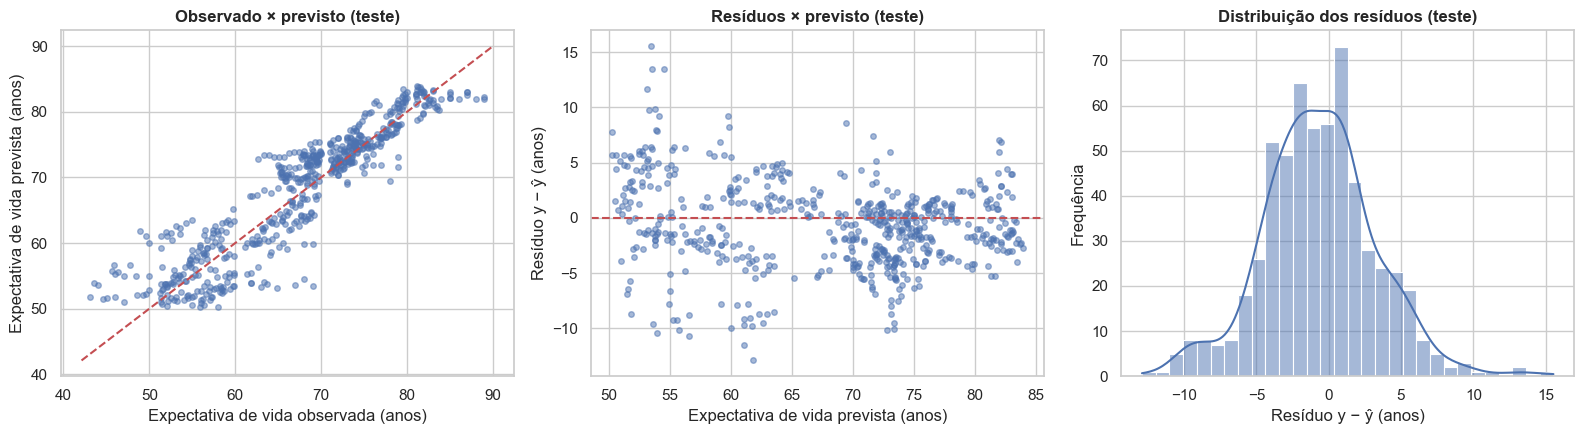

**Interpretação.** Viés médio (y − ŷ): **-0.660** anos; |erro| mediano 2.40; 90% dos erros absolutos ≤ 6.25 anos. Pontos próximos da diagonal indicam boa calibração; curvatura ou funil nos resíduos indicaria viés sistemático. Erro médio absoluto por região no teste:

,MAE (anos),n
regiao,,
Africa,4.33,192
Oceania,4.32,32
Americas,2.66,160
Asia,2.14,96
Europe,1.91,112


In [40]:
secao("4.7 (a)", "Desempenho final no teste: observado × previsto e análise de resíduos", "#4e342e")
# Desempenho final no teste: observado × previsto e análise de resíduos
res = y_teste.values - pred_teste
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].scatter(y_teste, pred_teste, alpha=.5, s=16); lim = [min(y_teste.min(), pred_teste.min()) - 1, max(y_teste.max(), pred_teste.max()) + 1]; axes[0].plot(lim, lim, "r--")
axes[0].set_xlabel("Expectativa de vida observada (anos)"); axes[0].set_ylabel("Expectativa de vida prevista (anos)"); axes[0].set_title("Observado × previsto (teste)")
axes[1].scatter(pred_teste, res, alpha=.5, s=16); axes[1].axhline(0, c="r", ls="--")
axes[1].set_xlabel("Expectativa de vida prevista (anos)"); axes[1].set_ylabel("Resíduo y − ŷ (anos)"); axes[1].set_title("Resíduos × previsto (teste)")
sns.histplot(res, kde=True, ax=axes[2], bins=30); axes[2].set_xlabel("Resíduo y − ŷ (anos)"); axes[2].set_ylabel("Frequência"); axes[2].set_title("Distribuição dos resíduos (teste)")
plt.tight_layout(); plt.show()
err_reg = pd.DataFrame({"regiao": df_teste["regiao"], "erro_abs": np.abs(res)}).dropna().groupby("regiao")["erro_abs"].agg(["mean", "count"]).sort_values("mean", ascending=False)
md(f"**Interpretação.** Viés médio (y − ŷ): **{res.mean():+.3f}** anos; |erro| mediano {np.median(np.abs(res)):.2f}; 90% dos erros absolutos ≤ {np.quantile(np.abs(res), .9):.2f} anos. "
   "Pontos próximos da diagonal indicam boa calibração; curvatura ou funil nos resíduos indicaria viés sistemático. Erro médio absoluto por região no teste:")
mostrar(err_reg.rename(columns={"mean": "MAE (anos)", "count": "n"}), fmt={"MAE (anos)": "{:.2f}", "n": "{:.0f}"})

### <span style="color:#4e342e">4.7 (b)</span> — Teste de consistência  

Observações do **teste** (países que o modelo nunca viu), usando apenas linhas com **todas as entradas observadas** (sem dado faltante), para que a mesma entrada possa ser digitada na aplicação Streamlit. Incluímos o caso de **menor erro absoluto**, o **mais difícil** (maior erro absoluto) e mais cinco casos aleatórios (`seed=42`). A seleção dos extremos usa o erro **apenas para interpretação**: não altera o modelo nem reabre a decisão.

In [36]:
secao("4.7 (b)", "Teste de consistência: ≥ 5 observações do teste com entrada, y real, previsão e erro individual", "#4e342e")
# (b) Teste de consistência: ≥ 5 observações do teste com entrada, y real, previsão e erro individual
assert set(df_teste["pais"]).isdisjoint(df_treino["pais"])
cons = df_teste.copy(); cons["previsto"] = pred_teste; cons["erro (y−ŷ)"] = cons[ALVO] - cons["previsto"]; cons["|erro|"] = cons["erro (y−ŷ)"].abs()
completos = cons.loc[cons[FEATURES].notna().all(axis=1)]
assert len(completos) >= 7, "Poucas linhas completas no teste para o teste de consistência"
i_bom, i_dificil = completos["|erro|"].idxmin(), completos["|erro|"].idxmax()
rng = np.random.RandomState(SEED); extras = rng.choice([i for i in completos.index if i not in (i_bom, i_dificil)], 5, replace=False)
sel = [i_bom, i_dificil] + list(extras)
papel_caso = {i_bom: "melhor caso", i_dificil: "caso difícil"}
tab_cons = cons.loc[sel, ["pais", "ano", "status", "regiao", "indice_renda", "escolaridade_anos", "pib_per_capita", "obitos_infantis", ALVO, "previsto", "erro (y−ŷ)", "|erro|"]].copy()
tab_cons.insert(0, "caso", [papel_caso.get(i, "aleatório") for i in sel]); tab_cons = tab_cons.rename(columns={ALVO: "y real", "previsto": "ŷ previsto"})
mostrar(tab_cons.reset_index(drop=True), fmt={"ano": "{:.0f}", "indice_renda": "{:.3f}", "escolaridade_anos": "{:.1f}", "pib_per_capita": "{:,.0f}", "obitos_infantis": "{:,.0f}",
                                              "y real": "{:.1f}", "ŷ previsto": "{:.2f}", "erro (y−ŷ)": "{:+.2f}", "|erro|": "{:.2f}"})
md(f"**Interpretação.** Melhor caso: **{cons.loc[i_bom, 'pais']} ({cons.loc[i_bom, 'ano']})**, erro {cons.loc[i_bom, 'erro (y−ŷ)']:+.2f} anos. "
   f"Caso difícil: **{cons.loc[i_dificil, 'pais']} ({cons.loc[i_dificil, 'ano']})**, erro {cons.loc[i_dificil, 'erro (y−ŷ)']:+.2f} anos. "
   f"Dos 7 casos, {(tab_cons['|erro|'] <= m_teste['MAE']).sum()} têm erro ≤ MAE do teste ({m_teste['MAE']:.2f}). Os casos de maior erro são observações para as quais o modelo teve mais dificuldade; "
   "uma possível explicação é a existência de fatores não observados na base, mas esta análise sozinha não confirma essa hipótese.")

<div style="background:#4e342e;color:white;padding:8px 14px;border-radius:6px;font-size:16px;margin:6px 0"><b>▶ 4.7 (b)</b> &nbsp;|&nbsp; Teste de consistência: ≥ 5 observações do teste com entrada, y real, previsão e erro individual</div>

,caso,pais,ano,status,regiao,indice_renda,escolaridade_anos,pib_per_capita,obitos_infantis,y real,ŷ previsto,erro (y−ŷ),|erro|
0,melhor caso,Peru,2012,Developing,Americas,0.725,13.4,"6,388",9,74.9,74.87,+0.03,0.03
1,caso difícil,Niger,2013,Developing,Africa,0.341,5.3,416,49,69.0,53.47,+15.53,15.53
2,aleatório,Indonesia,2008,Developing,Asia,0.641,11.7,217,149,67.7,69.72,-2.02,2.02
3,aleatório,Slovenia,2004,Developed,Europe,0.850,16.6,"1,727",0,77.2,77.57,-0.37,0.37
4,aleatório,Belize,2011,Developing,Americas,0.700,12.4,"4,516",0,69.4,72.79,-3.39,3.39
5,aleatório,Japan,2013,Developed,Asia,0.894,15.3,"4,454",2,83.5,80.81,+2.69,2.69
6,aleatório,Canada,2000,Developing,Americas,0.864,15.9,"24,124",2,79.1,80.63,-1.53,1.53


**Interpretação.** Melhor caso: **Peru (2012)**, erro +0.03 anos. Caso difícil: **Niger (2013)**, erro +15.53 anos. Dos 7 casos, 5 têm erro ≤ MAE do teste (3.06). Os casos de maior erro são observações para as quais o modelo teve mais dificuldade; uma possível explicação é a existência de fatores não observados na base, mas esta análise sozinha não confirma essa hipótese.

### <span style="color:#4e342e">4.7 (c)</span> — Artefatos para GitHub e Streamlit, e teste de paridade  

O artefato salvo é o **próprio `Pipeline` avaliado no teste** (pré-processamento + modelo). A aplicação apenas carrega com `joblib.load` e chama `predict` num `DataFrame` com **as mesmas colunas** de `FEATURES` (listadas em `meta.json`) — nenhum segundo pipeline é criado. As recodificações determinísticas da 4.2 (zero → ausente) foram aplicadas à base antes do pipeline; na interface, os campos numéricos devem aceitar valores válidos (faixas do `meta.json`) ou "não informado" (que o pipeline imputa).

In [37]:
secao("4.7 (c)", "Exportação: salva o pipeline final, os metadados e o caso de paridade para o Streamlit", "#4e342e")
# Exportação: salva o pipeline final, os metadados e o caso de paridade para o Streamlit
def _json_seguro(v):
    if isinstance(v, (np.integer,)): return int(v)
    if isinstance(v, (np.floating, float)): return None if np.isnan(v) else float(v)
    return v

base_export = df_tratado.copy(); base_export["conjunto"] = np.where(base_export["pais"].isin(df_teste["pais"]), "teste", "treino")   # o app explora só o treino
base_export.to_csv(DIR_DADOS / "base_tratada.csv", index=False)
joblib.dump(modelo_final, "modelo/modelo_final.joblib")

UNIDADES = {v[0]: v[3] for v in DIC_BASE}
dicionario_variaveis = [{"variavel": v, "descricao": sig, "unidade": UNIDADES.get(v, ""),
                         "tipo": ("categórica" if v in VARS_CAT else "numérica" if v in VARS_NUM else "texto/identificador" if v == "pais" else "numérica"),
                         "usada_no_modelo": v in FEATURES, "justificativa": DIC_USO[v][1]}
                        for v, _t, sig, _u in DIC_BASE if v != ALVO]

i_par = sel[2]                                   # um dos casos aleatórios do teste de consistência (linha completa)
entrada_par = {c: _json_seguro(X_teste.loc[i_par, c]) for c in FEATURES}
casos_paridade = [{"pais": cons.loc[k, "pais"], "ano": int(cons.loc[k, "ano"]), "entrada": {c: _json_seguro(X_teste.loc[k, c]) for c in FEATURES},
                   "y_real": float(cons.loc[k, ALVO]), "previsao_notebook": float(cons.loc[k, "previsto"])} for k in sel]   # os 7 casos do teste de consistência
meta = {
  "projeto": "Checkpoint 5 — Expectativa de vida (regressão)", "alvo": ALVO, "unidade_alvo": "anos",
  "configuracao_escolhida": CONFIG_ESCOLHIDA, "modelo": MODELO_ESCOLHIDO, "estrategia": ESTRATEGIA_ESCOLHIDA,
  "hiperparametros": {k: _json_seguro(v) for k, v in PARAMS_ESCOLHIDOS.items()},
  "hiperparametros_efetivos": {k: _json_seguro(v) for k, v in params_efetivos(MODELO_ESCOLHIDO, PARAMS_ESCOLHIDOS).items()},
  "features": FEATURES, "features_numericas": VARS_NUM, "features_categoricas": VARS_CAT, "variaveis_excluidas": EXCLUIDAS,
  "faixas_numericas": {c: [_json_seguro(X_treino[c].min()), _json_seguro(X_treino[c].max()), _json_seguro(X_treino[c].median())] for c in VARS_NUM},
  "categorias": {c: sorted(X_treino[c].dropna().unique().tolist()) for c in VARS_CAT},
  "metricas_teste": m_teste, "rmse_cv": [_json_seguro(esc["RMSE CV (média)"]), _json_seguro(esc["RMSE CV (dp)"])],
  "caso_paridade": {"pais": cons.loc[i_par, "pais"], "ano": int(cons.loc[i_par, "ano"]), "entrada": entrada_par,
                    "y_real": float(cons.loc[i_par, ALVO]), "previsao_notebook": float(cons.loc[i_par, "previsto"])},
  "versoes": {"python": platform.python_version(), "scikit-learn": sklearn.__version__, "xgboost": xgboost.__version__,
              "lightgbm": lightgbm.__version__, "optuna": optuna.__version__, "pandas": pd.__version__, "numpy": np.__version__},
  "seed": SEED,
  "casos_paridade": casos_paridade, "tolerancia_paridade": {"rtol": 1e-9, "atol": 1e-6},
  "pergunta": "Dadas características socioeconômicas, demográficas e de gasto em saúde observadas para um país em determinado ano, prever a expectativa de vida ao nascer daquele país-ano.",
  "fonte": "Life Expectancy (WHO) — Kaggle (kumarajarshi/life-expectancy-who); regiões: tabela ISO auxiliar",
  "n_observacoes": int(len(df_tratado)), "n_paises": int(df_tratado["pais"].nunique()), "n_treino": int(len(df_treino)), "n_teste": int(len(df_teste)),
  "dicionario_variaveis": dicionario_variaveis, "rotulos": {c: rot(c) for c in FEATURES + [ALVO]},
  "tipos_numericos": {c: ("inteiro" if X_treino[c].dropna().astype(float).apply(float.is_integer).all() else "decimal") for c in VARS_NUM},
  "categoria_padrao": {c: X_treino[c].mode().iloc[0] for c in VARS_CAT},
  "regra_selecao": "1 erro-padrão sobre o melhor RMSE médio de CV; entre as elegíveis, menor gap treino-validação e depois menor tempo de ajuste (definida antes do teste)",
}
with open("modelo/meta.json", "w", encoding="utf-8") as f: json.dump(meta, f, ensure_ascii=False, indent=2)
tab_cons.to_csv("modelo/teste_consistencia.csv", index=False)

comp9 = tab9[COLS9].copy(); comp9["hiperparametros"] = tab9["params"].apply(lambda p: json.dumps({k: _json_seguro(v) for k, v in p.items()}, ensure_ascii=False))
comp9["elegivel_1se"] = comp9["configuração"].isin(elegiveis["configuração"]); comp9["selecionada"] = comp9["configuração"].eq(CONFIG_ESCOLHIDA)
comp9.to_csv("modelo/comparacao_configuracoes.csv", index=False)
pd.DataFrame({"variavel": perm_m.index, "rotulo": [rot(c) for c in perm_m.index], "importancia_media": perm_m.values, "desvio_entre_folds": perm_sd.values}).to_csv("modelo/importancia_permutacao.csv", index=False)
pd.DataFrame({"variavel": nativa.index, "rotulo": [rot(c) for c in nativa.index], "importancia": nativa.values}).to_csv("modelo/importancia_nativa.csv", index=False)
pd.DataFrame({"pais": df_teste["pais"], "ano": df_teste["ano"], "status": df_teste["status"], "regiao": df_teste["regiao"],
              "y_real": y_teste.values, "y_previsto": pred_teste, "residuo": y_teste.values - pred_teste}).to_csv("modelo/predicoes_teste.csv", index=False)

# Paridade (lado notebook): recarrega o artefato e reproduz o caso
modelo_recarregado = joblib.load("modelo/modelo_final.joblib")
entrada_df = pd.DataFrame([meta["caso_paridade"]["entrada"]])[FEATURES]
pred_recarregada = float(modelo_recarregado.predict(entrada_df)[0])
assert abs(pred_recarregada - meta["caso_paridade"]["previsao_notebook"]) < 1e-6, "Artefato salvo diverge do pipeline em memória!"
X_todos = pd.DataFrame([c["entrada"] for c in casos_paridade])[FEATURES].astype({c: float for c in VARS_NUM})
assert np.allclose(modelo_recarregado.predict(X_todos), [c["previsao_notebook"] for c in casos_paridade], rtol=1e-9, atol=1e-6), "Paridade falhou em algum caso!"
md("Artefatos salvos: `modelo/modelo_final.joblib`, `modelo/meta.json`, `modelo/comparacao_configuracoes.csv`, `modelo/importancia_permutacao.csv`, `modelo/importancia_nativa.csv`, "
   "`modelo/predicoes_teste.csv`, `modelo/teste_consistencia.csv` e `dados/base_tratada.csv`.")
md(f"**Paridade (lado notebook) ✅** — caso **{meta['caso_paridade']['pais']} ({meta['caso_paridade']['ano']})**: previsão em memória = {meta['caso_paridade']['previsao_notebook']:.4f} "
   f"= previsão do artefato recarregado ({pred_recarregada:.4f}). **Para o teste de paridade com o Streamlit**, digite na aplicação a entrada abaixo e confirme que a previsão exibida é {pred_recarregada:.2f} anos:")
mostrar(pd.Series(meta["caso_paridade"]["entrada"], name="valor de entrada").astype(str).to_frame())

<div style="background:#4e342e;color:white;padding:8px 14px;border-radius:6px;font-size:16px;margin:6px 0"><b>▶ 4.7 (c)</b> &nbsp;|&nbsp; Exportação: salva o pipeline final, os metadados e o caso de paridade para o Streamlit</div>

Artefatos salvos: `modelo/modelo_final.joblib`, `modelo/meta.json`, `modelo/comparacao_configuracoes.csv`, `modelo/importancia_permutacao.csv`, `modelo/importancia_nativa.csv`, `modelo/predicoes_teste.csv`, `modelo/teste_consistencia.csv` e `dados/base_tratada.csv`.

**Paridade (lado notebook) ✅** — caso **Indonesia (2008)**: previsão em memória = 69.7182 = previsão do artefato recarregado (69.7182). **Para o teste de paridade com o Streamlit**, digite na aplicação a entrada abaixo e confirme que a previsão exibida é 69.72 anos:

,valor de entrada
ano,2008
alcool,0.07
gasto_saude_pct_pib_pc,10.26341108
gasto_saude_total_pct,2.81
obitos_infantis,149
pib_per_capita,216.52766
populacao,236159276.0
magreza_1_19,1.7
indice_renda,0.641
escolaridade_anos,11.7
